<a href="https://colab.research.google.com/github/EdwAte/Preparacion_Datos/blob/main/EDA_Analitica1_Entregable_final_(TUG).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

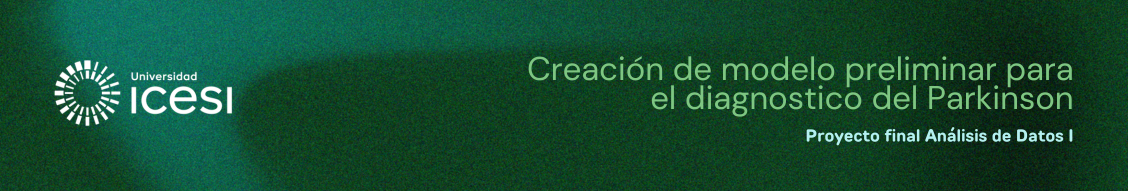

#**Analítica de Datos I**
#Integrantes:
*   Miguel Angel Silva - A00413793
*   Edward Duván Aterhortúa - A00430873
*   Daniel Stiven Alarcon - A00423608
*   Juan José Ramírez - A00394509




# **Resumen 🤖🩺**


En este cuaderno se analizan datos de la prueba Timed Up and Go (TUG) para apoyar el diagnóstico preliminar de la enfermedad de Parkinson, a partir del dataset Gait Assessment in Parkinson Disease. Se busca identificar patrones que diferencien a pacientes con Parkinson de personas del grupo control, usando variables relacionadas con marcha, tiempos, aceleraciones y giros.

Se evalúa el desempeño de modelos analíticos mediante métricas como exactitud, sensibilidad (Recall), precisión, F1-score, matriz de confusión y ROC-AUC. El propósito es aportar una herramienta de apoyo clínico que ayude a mejorar la toma de decisiones, optimizar tiempos de evaluación y fortalecer la atención médica.

#*Pregunta SMART*
¿Puede un modelo de clasificación basado en datos de la prueba TUG alcanzar una sensibilidad y especificidad superiores al 85% en la detección de enfermedad de Parkinson durante su validación clínica?


#**Análisis Exploratorio de los datos**
##Cargue de librerías

En esta primera sección del notebook se realiza la instalación y posterior importación de todas las librerías y módulos necesarios para el desarrollo del proyecto de clasificación. Previo a las importaciones, se ejecuta la instalación de la librería imbalanced-learn mediante el comando pip install imblearn, lo cual garantiza la disponibilidad de esta dependencia en el entorno de ejecución antes de ser utilizada.
Para el manejo y análisis de datos se importan pandas y numpy, herramientas fundamentales para la manipulación de estructuras tabulares y operaciones numéricas. Complementariamente, se incorporan matplotlib.pyplot y seaborn para la generación de visualizaciones estadísticas y exploratorias.
Desde el ecosistema de scikit-learn se importan diversos componentes que cubren las distintas etapas del flujo de trabajo: la partición y validación de datos mediante train_test_split, StratifiedKFold y cross_validate; el tratamiento de valores faltantes con KNNImputer y SimpleImputer; el escalado de variables a través de StandardScaler, RobustScaler, MinMaxScaler y PowerTransformer; y la construcción de flujos de preprocesamiento con Pipeline y ColumnTransformer. Adicionalmente, se incorporan herramientas de selección de características como SelectKBest, f_classif, mutual_info_classif, LassoCV y RFE, junto con los modelos de clasificación LogisticRegression y RandomForestClassifier, y un conjunto amplio de métricas de evaluación que incluye AUC-ROC, exactitud, precisión, recall, F1 y matriz de confusión.
Finalmente, se importan SMOTE e ImbPipeline desde la librería imbalanced-learn. El primero corresponde a la técnica de sobremuestreo sintético Synthetic Minority Oversampling Technique, utilizada para equilibrar conjuntos de datos donde una clase tiene significativamente menos ejemplos que otra. El segundo es una versión adaptada de Pipeline que garantiza que el balanceo mediante SMOTE se aplique exclusivamente sobre el conjunto de entrenamiento y nunca sobre el de prueba, evitando así una fuga de información que podría sesgar los resultados del modelo.

In [1]:
pip install imblearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report,
                             RocCurveDisplay)
# Opcionales para balanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


#Cargue de los datos
Carga de los datos
Se importa el conjunto de datos correspondiente a la prueba Timed Up and Go (TUG) desde un archivo con formato .csv. Una vez cargados, se realiza una visualización preliminar de los mismos con el fin de inspeccionar su estructura, identificar las variables disponibles y comprender la forma en que se encuentran organizados antes de proceder con su procesamiento.

In [4]:
from google.colab import drive
import pandas as pd

df = pd.read_csv('/content/TUG_TABLE_1.csv', encoding='UTF8', sep=';')


In [5]:
df.head()

,ID,Estado,Mean stride amplitude (cm),SD stride amplitude (cm),Mean stride speed (cm/s),SD stride speed,Mean speed correlation,Mean height of foot lift (cm),SD height of foot lift (cm),Arm swing indicator,Gait evaluation MDS-UPDRS,Target
0,1 R,Paciente,127,4,111,2,0.96,9.30,1.43,0.82,0,1
1,2 R,Paciente,83,12,85,13,0.77,9.16,0.55,0.82,1,1
2,3 L,Paciente,75,6,75,11,0.88,8.66,0.65,0.82,1,1
3,4 R,Paciente,83,7,90,7,0.96,7.14,0.51,0.38,1,1
4,5 L,Paciente,75,8,81,10,0.97,6.82,0.88,0.38,1,1


Visualiza las primeras filas

In [6]:
print(df.shape)
print(df.columns)

(42, 12)
Index(['ID', 'Estado', 'Mean stride amplitude (cm)',
       'SD stride amplitude (cm)', 'Mean stride speed (cm/s)',
       'SD stride speed', 'Mean speed correlation',
       'Mean height of foot lift (cm)', 'SD height of foot lift (cm)',
       'Arm swing indicator', 'Gait evaluation MDS-UPDRS', 'Target'],
      dtype='object')


#Inspección inicial del conjunto de datos
Se realiza una revisión preliminar del conjunto de datos con el objetivo de conocer su estructura interna y detectar posibles inconsistencias. Para ello, se emplea el método df.info(), el cual permite obtener información general sobre el DataFrame, incluyendo el número de registros, el nombre y tipo de dato de cada variable, así como la cantidad de valores no nulos presentes en cada columna. Complementariamente, se aplica df.isnull().sum() para cuantificar de forma explícita los valores faltantes por variable, lo cual resulta fundamental para determinar qué variables requerirán un tratamiento de imputación en etapas posteriores. Finalmente, se verifica la existencia de registros duplicados mediante df.duplicated().sum(), con el propósito de garantizar la integridad del conjunto de datos y evitar que observaciones repetidas introduzcan sesgos en el análisis.

In [7]:
# Tipos y nulos
print(df.info())
print(df.isnull().sum())

# Duplicados
print("Duplicados:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             42 non-null     object 
 1   Estado                         42 non-null     object 
 2   Mean stride amplitude (cm)     42 non-null     int64  
 3   SD stride amplitude (cm)       42 non-null     int64  
 4   Mean stride speed (cm/s)       42 non-null     int64  
 5   SD stride speed                42 non-null     int64  
 6   Mean speed correlation         42 non-null     float64
 7   Mean height of foot lift (cm)  42 non-null     float64
 8   SD height of foot lift (cm)    42 non-null     float64
 9   Arm swing indicator            42 non-null     float64
 10  Gait evaluation MDS-UPDRS      42 non-null     int64  
 11  Target                         42 non-null     int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 4.1

La inspección inicial revela que el conjunto de datos cuenta con 42 registros distribuidos en 12 variables. De estas, dos son de tipo object correspondientes a los campos ID y Estado, cuatro son de tipo float64 y seis de tipo int64, representando estas últimas las variables numéricas del análisis. Cabe destacar que no se identificaron valores faltantes en ninguna de las columnas ni registros duplicados, lo que indica que el conjunto de datos se encuentra completo e íntegro, reduciendo considerablemente la necesidad de intervenciones correctivas en la etapa de preprocesamiento.

#Distribución de clases
Se genera un gráfico de barras mediante sns.countplot() para visualizar la distribución de la variable objetivo Target, la cual distingue entre pacientes y controles dentro del conjunto de datos. Esta visualización permite identificar de forma rápida si existe un desbalance entre clases, situación que de presentarse podría afectar el desempeño de los modelos de clasificación y justificaría el uso de técnicas de balanceo como SMOTE, importada previamente.

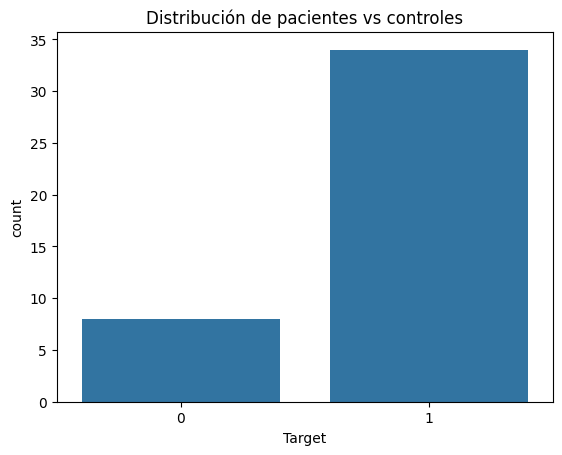

In [8]:
sns.countplot(x="Target", data=df)
plt.title("Distribución de pacientes vs controles")
plt.show()


Con el fin de complementar la visualización anterior, se cuantifica de forma numérica la distribución de la variable Target. Para ello se emplea value_counts(normalize=True), que permite obtener la proporción relativa de cada clase expresada en términos porcentuales, y groupby().size() para conocer el conteo absoluto de observaciones por clase. Estos resultados permiten determinar con precisión el grado de desbalance existente entre pacientes y controles, información clave para decidir si es necesario aplicar técnicas de balanceo en etapas posteriores del análisis.


In [9]:
# Target balance
print(df['Target'].value_counts(normalize=True))
print(df.groupby('Target').size())

Target
1    0.809524
0    0.190476
Name: proportion, dtype: float64
Target
0     8
1    34
dtype: int64


Los resultados confirman la existencia de un desbalance de clases considerable en el conjunto de datos. La clase mayoritaria, correspondiente a los pacientes (Target = 1), representa aproximadamente el 81% de las observaciones con 34 registros, mientras que la clase minoritaria, correspondiente a los controles (Target = 0), representa tan solo el 19% restante con 8 registros. Esta disparidad en la distribución refuerza la necesidad de aplicar técnicas de balanceo como SMOTE durante el entrenamiento de los modelos, con el objetivo de evitar que el clasificador desarrolle un sesgo hacia la clase mayoritaria y comprometa su capacidad predictiva sobre los casos de la clase minoritaria.

Se construye una tabla de contingencia mediante pd.crosstab() para examinar la relación entre la variable Gait evaluation MDS-UPDRS y la variable objetivo Target. Esta exploración permite identificar cómo se distribuyen los distintos valores de la escala de evaluación de la marcha MDS-UPDRS en función de la clase a la que pertenece cada observación, lo que resulta útil para determinar si dicha variable presenta un poder discriminativo relevante entre pacientes y controles, y si podría introducir redundancia o colinealidad con la variable objetivo en etapas posteriores del modelado.

In [10]:
# Revisión de la columna `Gait evaluation MDS-UPDRS` vs `Target`
tab = pd.crosstab(df['Gait evaluation MDS-UPDRS'], df['Target'])
print("Cross-tab Gait eval vs Target:\n", tab)

Cross-tab Gait eval vs Target:
 Target                     0   1
Gait evaluation MDS-UPDRS       
0                          8   9
1                          0  22
2                          0   3


Los resultados de la tabla de contingencia revelan un patrón relevante en la relación entre la escala Gait evaluation MDS-UPDRS y la variable Target. Se observa que todos los sujetos de control (Target = 0) presentan una puntuación de 0 en dicha escala, mientras que los pacientes (Target = 1) se distribuyen entre las puntuaciones 0, 1 y 2. Esto indica que la variable no es completamente discriminativa por sí sola, dado que 9 pacientes comparten la puntuación más baja con los controles. Sin embargo, las puntuaciones 1 y 2 son exclusivas de la clase de pacientes, lo que sugiere una asociación parcial con la variable objetivo. Esta situación amerita considerar con cautela el peso que se le otorga a esta variable durante el modelado, ya que podría introducir cierto grado de redundancia con la variable Target.

Con el fin de facilitar la interpretación visual de la tabla de contingencia obtenida previamente, se construye manualmente un DataFrame con los valores ya calculados y se representa gráficamente mediante un mapa de calor utilizando sns.heatmap(). Esta visualización permite apreciar de forma intuitiva la distribución de frecuencias entre los niveles de la escala Gait evaluation MDS-UPDRS y las clases de la variable Target, donde la intensidad del color refleja la concentración de observaciones en cada celda. De esta manera, se refuerza visualmente el patrón identificado anteriormente, evidenciando que los valores más altos de la escala se asocian exclusivamente con la clase de pacientes.

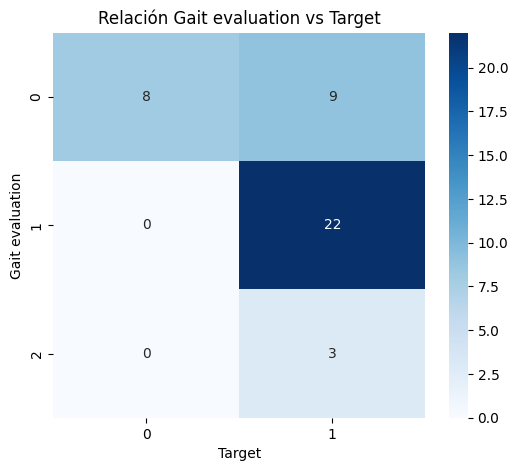

In [11]:
ct = pd.DataFrame({
    0: [8, 0, 0],
    1: [9, 22, 3]
}, index=[0,1,2])

ct.index.name = "Gait evaluation"
ct.columns.name = "Target"

plt.figure(figsize=(6,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title("Relación Gait evaluation vs Target")
plt.show()

Complementando la visualización anterior, se genera un segundo mapa de calor en el que los valores absolutos son transformados a proporciones porcentuales por fila mediante ct.div(ct.sum(axis=1), axis=0). Esto permite analizar, para cada nivel de la escala Gait evaluation MDS-UPDRS, qué porcentaje de las observaciones corresponde a cada clase. Esta perspectiva normalizada resulta más informativa que los conteos absolutos en contextos de desbalance de clases, ya que facilita la comparación entre niveles independientemente del número de observaciones que contenga cada uno.

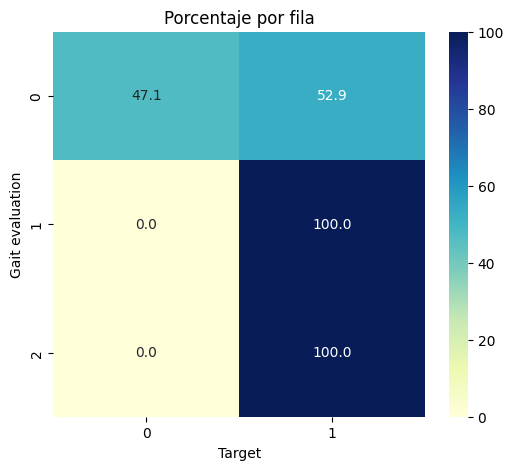

In [12]:
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(6,5))
sns.heatmap(ct_percent, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title("Porcentaje por fila")
plt.show()

Con el propósito de evaluar el poder predictivo individual de la variable Gait evaluation MDS-UPDRS, se construye una versión binarizada de la misma denominada Gait_binary, asignando el valor 1 a toda puntuación mayor a 0 y el valor 0 en caso contrario. Esta transformación permite tratar dicha variable como un clasificador independiente y confrontarla directamente contra la variable Target mediante una matriz de confusión y un reporte de clasificación. De esta forma, se busca cuantificar en qué medida la escala de evaluación de la marcha por sí sola es capaz de discriminar entre pacientes y controles, lo que aporta evidencia adicional sobre su relevancia como variable predictora dentro del conjunto de datos.

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

df['Gait_binary'] = np.where(df['Gait evaluation MDS-UPDRS'] > 0, 1, 0)

cm = confusion_matrix(df['Target'], df['Gait_binary'])
print(cm)

print(classification_report(df['Target'], df['Gait_binary']))

[[ 8  0]
 [ 9 25]]
              precision    recall  f1-score   support

           0       0.47      1.00      0.64         8
           1       1.00      0.74      0.85        34

    accuracy                           0.79        42
   macro avg       0.74      0.87      0.74        42
weighted avg       0.90      0.79      0.81        42



Los resultados obtenidos revelan que la variable Gait_binary presenta un comportamiento asimétrico como clasificador independiente. Por un lado, alcanza una precisión perfecta (1.00) para la clase de pacientes (Target = 1), lo que indica que cuando predice un caso positivo, acierta en el 100% de las ocasiones. Sin embargo, su recall para esta misma clase es de 0.74, lo que significa que deja sin detectar aproximadamente el 26% de los pacientes, correspondiente a los 9 casos que obtuvieron una puntuación de 0 en la escala original. Para la clase de controles (Target = 0), se observa el comportamiento inverso: un recall perfecto (1.00) pero una precisión baja (0.47), reflejando que ningún control fue clasificado erróneamente como paciente. En términos globales, se obtiene una exactitud del 79%, lo que sugiere que si bien la variable Gait evaluation MDS-UPDRS posee cierta capacidad discriminativa, no es suficiente por sí sola para construir un clasificador robusto, por lo que su combinación con las demás variables del conjunto de datos resulta necesaria para mejorar el desempeño predictivo del modelo.

Se realiza una verificación de consistencia lógica entre la variable Gait evaluation MDS-UPDRS y la variable Target, identificando aquellos registros en los que un sujeto clasificado como paciente (Target = 1) presenta simultáneamente una puntuación de 0 en la escala de evaluación de la marcha. Desde una perspectiva clínica, esta combinación podría considerarse contradictoria, dado que se esperaría que los pacientes exhibieran algún grado de alteración en la marcha. Los registros que cumplan esta condición son extraídos y mostrados para su revisión, con el fin de determinar si corresponden a casos clínicamente válidos, errores de registro, o pacientes en etapas tempranas de la enfermedad donde aún no se manifiestan alteraciones detectables en la marcha.

In [14]:
# Detectar inconsistencias (ejemplo: gait eval = 0 pero Target=1)
inconsist = df[(df['Gait evaluation MDS-UPDRS'] == 0) & (df['Target'] == 1)]
print("Inconsistencias (Gait=0 pero Target=1):", len(inconsist))
# Si hay filas, muéstralas para revisión clínica
inconsist

Inconsistencias (Gait=0 pero Target=1): 9


,ID,Estado,Mean stride amplitude (cm),SD stride amplitude (cm),Mean stride speed (cm/s),SD stride speed,Mean speed correlation,Mean height of foot lift (cm),SD height of foot lift (cm),Arm swing indicator,Gait evaluation MDS-UPDRS,Target,Gait_binary
0,1 R,Paciente,127,4,111,2,0.96,9.30,1.43,0.82,0,1,0
12,13 R,Paciente,115,8,105,6,0.93,9.83,0.40,1.18,0,1,0
13,14 L,Paciente,117,7,101,13,0.95,8.78,0.91,1.18,0,1,0
16,17 R,Paciente,108,10,84,8,0.97,8.05,1.56,2.24,0,1,0
17,18 L,Paciente,101,5,79,4,0.96,8.01,0.40,2.24,0,1,0
18,19 R,Paciente,110,11,102,18,0.95,6.33,1.38,2.29,0,1,0
19,20 L,Paciente,114,14,103,13,0.95,6.24,1.17,2.29,0,1,0
26,27 R,Paciente,123,16,115,18,0.96,12.04,1.93,1.86,0,1,0
27,28 L,Paciente,130,8,122,12,0.94,12.59,1.34,1.86,0,1,0


**Identificación de Falsos Negativos:** Se identificaron 9 registros que presentan esta inconsistencia, todos ellos correspondientes a sujetos clasificados como pacientes en la columna Estado, pero con una puntuación de 0 en la escala Gait evaluation MDS-UPDRS. Al examinar estos casos, se observa que sus valores en las demás variables biomecánicas, como la amplitud y velocidad de zancada, la altura del levantamiento del pie y el indicador de balanceo de brazos, no presentan patrones claramente anómalos que los distingan del resto de los pacientes. Esto sugiere que estos 9 casos podrían corresponder a pacientes en estadios tempranos de la enfermedad, en los cuales las alteraciones de la marcha aún no son suficientemente pronunciadas para reflejarse en la escala MDS-UPDRS, pero que clínicamente ya han sido diagnosticados como pacientes. Esta situación refuerza la importancia de no depender exclusivamente de la variable Gait evaluation MDS-UPDRS como predictor, y justifica el uso conjunto de las demás variables biomecánicas para construir un modelo de clasificación más robusto.

#Estadísticas descriptivas
Se calculan las estadísticas descriptivas para el conjunto de variables numéricas del dataset. Para ello, se filtran únicamente las columnas cuyo tipo de dato corresponde a float64 o int64, excluyendo explícitamente las variables ID y Target por no ser variables de análisis. Sobre este subconjunto se aplica el método describe(), el cual retorna métricas de tendencia central y dispersión tales como la media, desviación estándar, valores mínimo y máximo, y los percentiles 25, 50 y 75 para cada variable. La transposición del resultado mediante .T facilita la lectura al presentar las variables como filas y las métricas como columnas, permitiendo una comparación más cómoda entre las distintas características biomecánicas del conjunto de datos.

In [15]:
# ---------- 3) Estadísticas descriptivas ----------
num_cols = [c for c in df.columns if df[c].dtype in [np.float64, np.int64] and c not in ['ID','Target']]
print(df[num_cols].describe().T)

                               count        mean        std    min      25%  \
Mean stride amplitude (cm)      42.0  101.952381  27.554781  21.00  93.2500   
SD stride amplitude (cm)        42.0    8.666667   3.620178   3.00   6.2500   
Mean stride speed (cm/s)        42.0   91.595238  26.159044  20.00  81.2500   
SD stride speed                 42.0   10.071429   4.805448   2.00   6.2500   
Mean speed correlation          42.0    0.914762   0.085831   0.51   0.9025   
Mean height of foot lift (cm)   42.0    8.491190   2.268237   3.48   6.8850   
SD height of foot lift (cm)     42.0    0.931429   0.403289   0.29   0.5875   
Arm swing indicator             42.0    1.203095   0.692917   0.38   0.6200   
Gait evaluation MDS-UPDRS       42.0    0.666667   0.611542   0.00   0.0000   
Gait_binary                     42.0    0.595238   0.496796   0.00   0.0000   

                                   50%       75%     max  
Mean stride amplitude (cm)     109.500  117.7500  142.00  
SD stride am

Los resultados de las estadísticas descriptivas permiten caracterizar el comportamiento de las variables biomecánicas del conjunto de datos. En cuanto a las variables relacionadas con la zancada, se observa que la amplitud media es de aproximadamente 102 cm con una desviación estándar de 27.5 cm, mientras que la velocidad media de zancada es de 91.6 cm/s con una dispersión similar, lo que sugiere una variabilidad moderada entre los sujetos. La correlación de velocidad media presenta valores cercanos a 1 (media de 0.91), indicando en general una marcha bastante regular, aunque el valor mínimo de 0.51 evidencia la presencia de algún caso con alteraciones importantes en el patrón de marcha.
La altura media del levantamiento del pie se sitúa en 8.49 cm con una desviación estándar de 2.27 cm, y el indicador de balanceo de brazos muestra una mayor variabilidad relativa, con una media de 1.20 y valores que oscilan entre 0.38 y 2.51, lo que podría reflejar diferencias clínicamente relevantes entre pacientes y controles. Respecto a la escala Gait evaluation MDS-UPDRS, su media de 0.67 y mediana de 1.0 son consistentes con la distribución observada anteriormente, donde la mayoría de los pacientes presentan puntuaciones bajas. En términos generales, no se identifican valores extremos que sugieran errores de medición evidentes, aunque la amplitud del rango en algunas variables justifica una exploración más detallada en la etapa de análisis de distribuciones.

#Distribución de variables por clase
Con el fin de explorar el comportamiento individual de cada variable biomecánica en función de la clase, se genera una serie de histogramas con curva de densidad (KDE) para cada variable numérica, excluyendo Gait evaluation MDS-UPDRS dado que fue analizada previamente de forma independiente. Cada gráfico muestra la distribución de la variable diferenciada por la clase Target, utilizando el parámetro common_norm=False para normalizar las densidades de forma independiente por clase, lo que permite una comparación justa entre grupos aun cuando existe un desbalance en el número de observaciones. Esta visualización resulta fundamental para identificar qué variables presentan mayor separación entre las distribuciones de pacientes y controles, anticipando así cuáles podrían tener un mayor poder discriminativo en los modelos de clasificación.

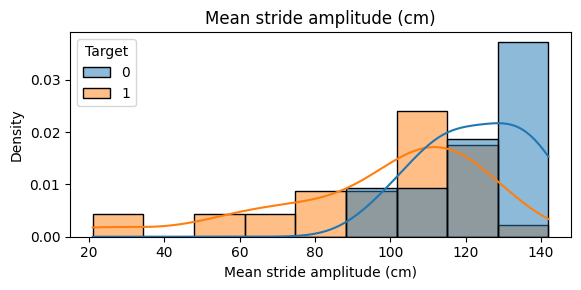

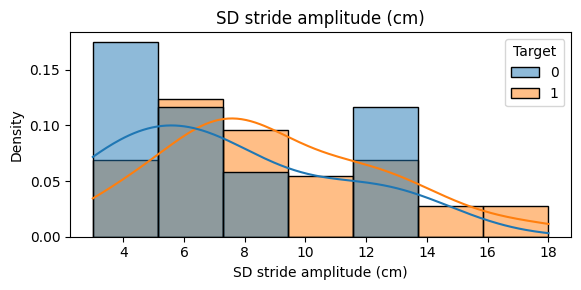

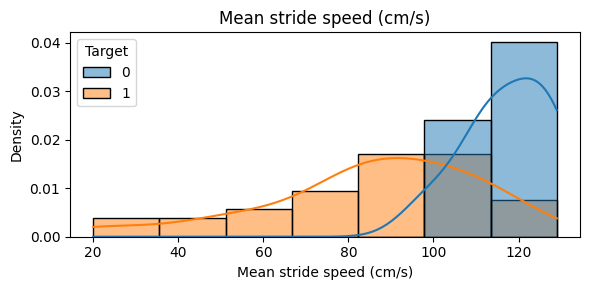

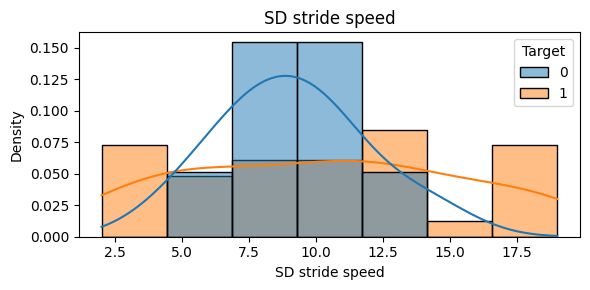

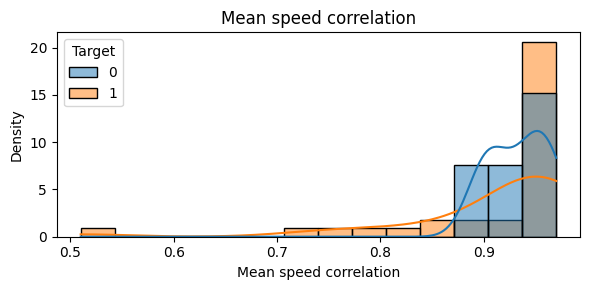

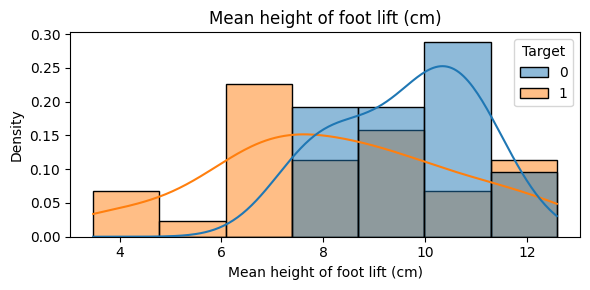

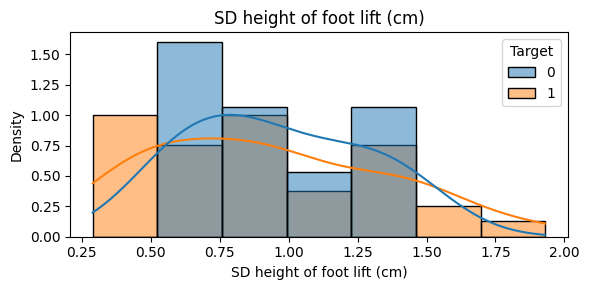

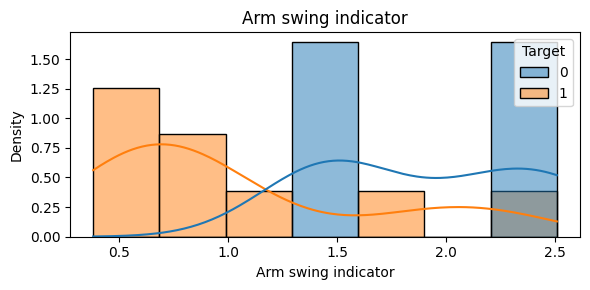

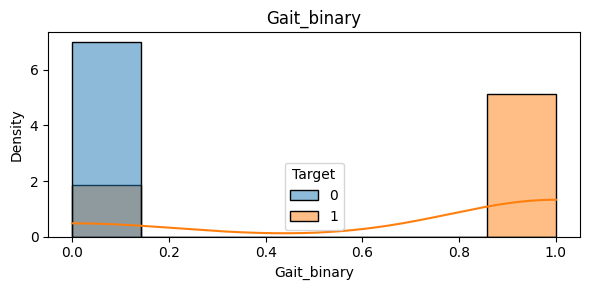

In [16]:
cols_to_plot = [col for col in num_cols if col != 'Gait evaluation MDS-UPDRS']

for col in cols_to_plot:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df, x=col, hue='Target',
                 kde=True, stat="density", common_norm=False)
    plt.title(col)
    plt.tight_layout()
    plt.show()

Los histogramas generados permiten identificar diferencias relevantes en la distribución de las variables biomecánicas entre pacientes y controles. En cuanto a la amplitud y velocidad media de zancada, se observa que los controles (Target = 0) tienden a concentrarse en valores más altos, mientras que los pacientes (Target = 1) presentan una distribución más dispersa y desplazada hacia valores menores, lo que sugiere que los pacientes exhiben una marcha de menor amplitud y velocidad. Un patrón similar se aprecia en la desviación estándar de la velocidad de zancada, donde los controles muestran una distribución más estrecha y centrada, en contraste con la mayor variabilidad observada en los pacientes.
El indicador de balanceo de brazos (Arm swing indicator) muestra una separación notable entre clases, con los controles concentrados en valores bajos y los pacientes distribuidos hacia valores más altos, lo que podría indicar alteraciones en la coordinación del movimiento de los brazos durante la marcha. Por su parte, la correlación de velocidad media presenta distribuciones similares entre ambas clases con ligeras diferencias en la cola izquierda, mientras que la altura media del levantamiento del pie muestra una distribución más amplia en los pacientes. Finalmente, la variable Gait_binary refleja de forma clara el desbalance de clases previamente identificado. En términos generales, las variables relacionadas con la amplitud, velocidad y el balanceo de brazos parecen ser las más prometedoras en términos de capacidad discriminativa entre ambas clases.

#Matriz de correlación
Se construye una matriz de correlación de Pearson sobre el conjunto de variables numéricas, incluyendo la variable Target, con el fin de examinar las relaciones lineales existentes entre las distintas características biomecánicas y su asociación con la variable objetivo. La matriz es visualizada mediante un mapa de calor con escala de color divergente (coolwarm), centrada en cero, donde los tonos rojos indican correlaciones positivas, los azules correlaciones negativas, y los colores neutros ausencia de correlación lineal. La anotación de los coeficientes sobre cada celda facilita la lectura precisa de los valores, permitiendo identificar tanto variables altamente correlacionadas entre sí, lo que podría sugerir redundancia de información, como aquellas con mayor asociación lineal con la variable Target, lo que orientará la etapa de selección de características.

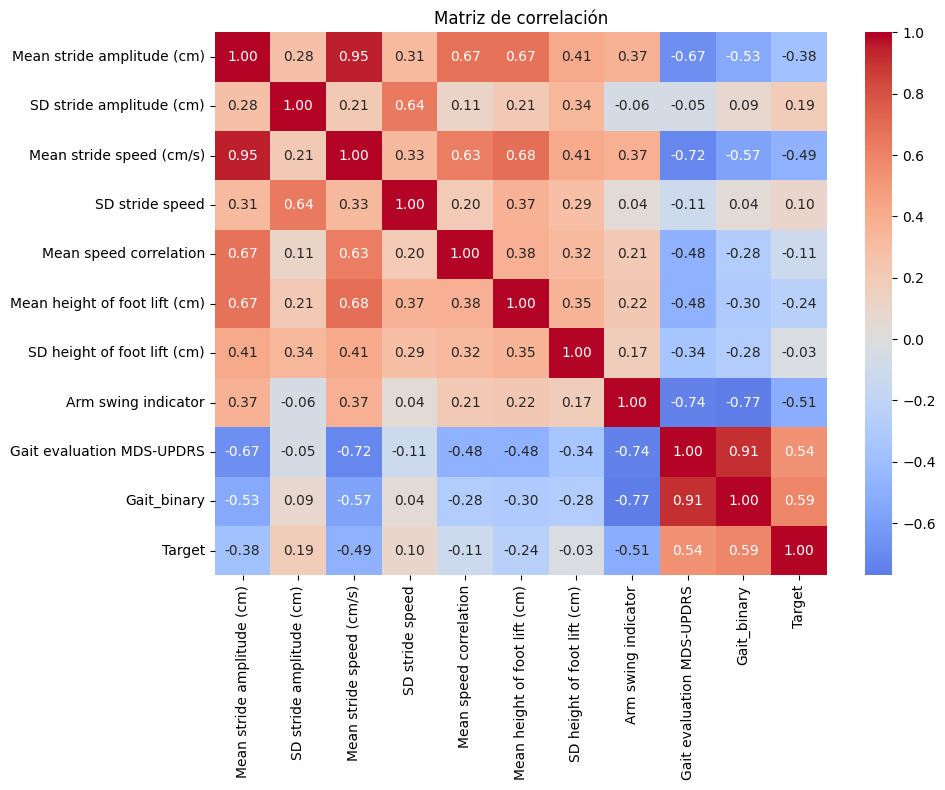

In [17]:
# ---------- 4) Correlación ----------
corr = df[num_cols + ['Target']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.tight_layout()

La matriz de correlación revela patrones de asociación relevantes entre las variables biomecánicas. El hallazgo más destacado es la correlación muy alta (0.95) entre la amplitud media de zancada y la velocidad media de zancada, lo que indica una fuerte redundancia entre ambas variables y sugiere que podrían estar capturando información biomecánica similar. Esta multicolinealidad deberá ser considerada durante la etapa de selección de características.
Respecto a la relación con la variable Target, las correlaciones más fuertes se observan con Gait_binary (0.59) y Gait evaluation MDS-UPDRS (0.54), seguidas por el indicador de balanceo de brazos con una correlación negativa de -0.51 y la velocidad media de zancada con -0.49, lo que indica que valores más bajos de estas variables tienden a asociarse con la clase de pacientes. Cabe destacar que Gait evaluation MDS-UPDRS y Gait_binary presentan una correlación de 0.91 entre sí, lo que era esperado dado que la segunda fue derivada directamente de la primera, por lo que incluir ambas simultáneamente en el modelo podría introducir redundancia innecesaria. En términos generales, la matriz sugiere que el Arm swing indicator y las variables de velocidad y amplitud de zancada son las que mayor información aportan para discriminar entre clases.

Con el fin de identificar de forma sistemática las variables que presentan una correlación elevada entre sí, se implementa una inspección programática que recorre todos los pares posibles de variables numéricas y filtra aquellos cuyo coeficiente de correlación de Pearson supera en valor absoluto el umbral de 0.70. Los pares identificados son almacenados junto con su coeficiente correspondiente, permitiendo tener un registro explícito de las relaciones de alta colinealidad presentes en el conjunto de datos. Esta información resulta de utilidad práctica para la etapa de selección de características, donde la presencia de variables altamente correlacionadas podría justificar la eliminación de alguna de ellas con el fin de reducir la redundancia de información y mejorar la interpretabilidad y estabilidad de los modelos de clasificación.

In [18]:
# Inspección de correlaciones altas (>0.85)
high_corr = []
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        if abs(df[c1].corr(df[c2])) > 0.70:
            high_corr.append((c1,c2, df[c1].corr(df[c2])))
print("Pares con alta correlación (>0.85):", high_corr)

Pares con alta correlación (>0.85): [('Mean stride amplitude (cm)', 'Mean stride speed (cm/s)', np.float64(0.9453225874086371)), ('Mean stride speed (cm/s)', 'Gait evaluation MDS-UPDRS', np.float64(-0.7160735826822736)), ('Arm swing indicator', 'Gait evaluation MDS-UPDRS', np.float64(-0.7377064865344318)), ('Arm swing indicator', 'Gait_binary', np.float64(-0.769984304930571)), ('Gait evaluation MDS-UPDRS', 'Gait_binary', np.float64(0.9098494858802322))]


Los resultados confirman la existencia de cinco pares de variables con correlación superior a 0.70. El par más destacado es el conformado por la amplitud media de zancada y la velocidad media de zancada, con un coeficiente de 0.945, lo que representa una correlación casi perfecta y evidencia una redundancia considerable entre ambas variables. El segundo par de mayor relevancia es Gait evaluation MDS-UPDRS y Gait_binary con un coeficiente de 0.910, lo cual era previsible dado que la segunda fue construida directamente a partir de la primera, por lo que mantener ambas en el modelo aportaría información prácticamente idéntica.
Adicionalmente, se identifican correlaciones negativas moderadamente altas entre el Arm swing indicator y las variables Gait_binary (-0.770) y Gait evaluation MDS-UPDRS (-0.738), así como entre la velocidad media de zancada y la escala Gait evaluation MDS-UPDRS (-0.716), lo que sugiere que a mayor velocidad y balanceo de brazos, menor puntuación en la escala de evaluación de la marcha. Estos hallazgos refuerzan la necesidad de aplicar técnicas de selección de características que permitan reducir la multicolinealidad y conservar únicamente las variables con mayor aporte informativo independiente para el modelo.

#Análisis de relaciones entre variables
Se genera un gráfico de pares (pairplot) que permite visualizar simultáneamente las relaciones bivariadas entre todas las variables numéricas del conjunto de datos, diferenciando por color la clase a la que pertenece cada observación. En la diagonal se muestran las distribuciones univariadas de cada variable por clase, mientras que en los paneles fuera de la diagonal se representan los diagramas de dispersión entre cada par de variables. Esta visualización complementa los hallazgos de la matriz de correlación, permitiendo identificar no solo la fuerza de las relaciones lineales entre variables, sino también posibles patrones no lineales y la separabilidad visual entre las clases de pacientes y controles en el espacio de características.

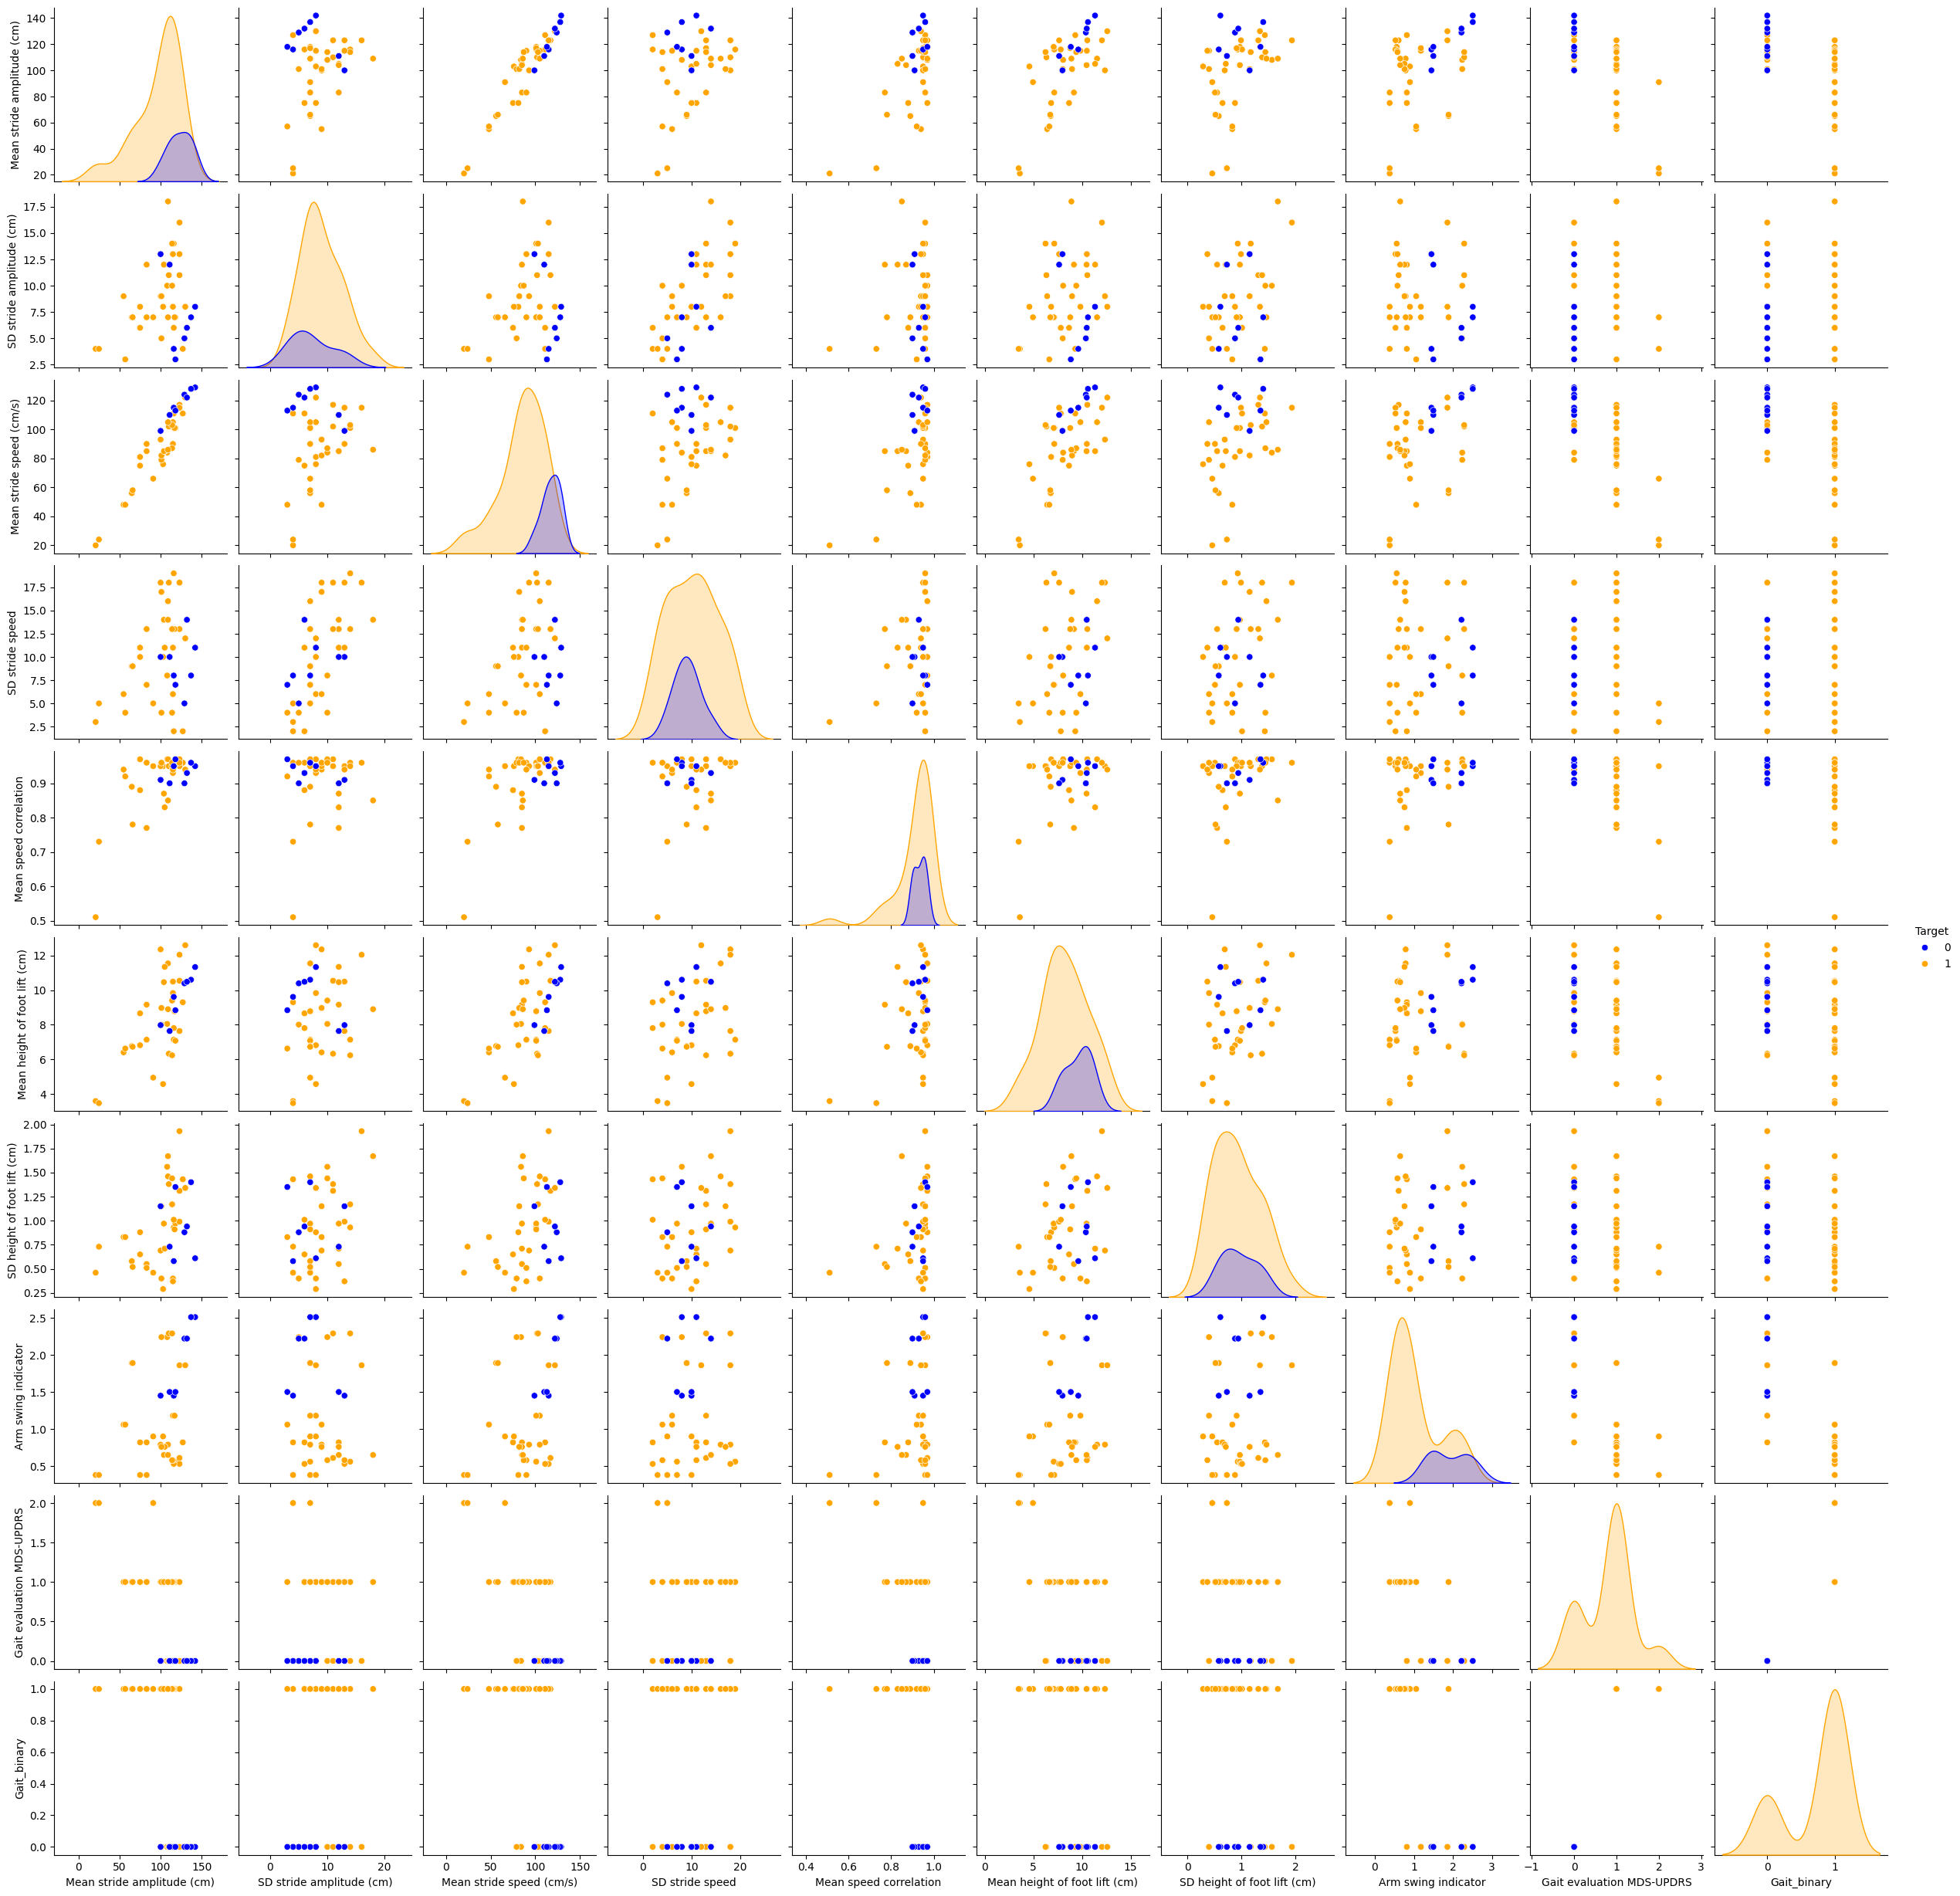

In [19]:
sns.pairplot(df, hue="Target", palette={0: "blue", 1: "orange"})
plt.show()

El pairplot generado permite consolidar visualmente los hallazgos obtenidos en los análisis previos. En la diagonal se confirma lo observado en los histogramas individuales: variables como la amplitud media de zancada, la velocidad media de zancada y el indicador de balanceo de brazos presentan distribuciones con cierto grado de separación entre clases, mientras que otras como la desviación estándar de la amplitud de zancada muestran distribuciones muy solapadas, lo que anticipa un menor poder discriminativo.
En los paneles de dispersión fuera de la diagonal, la alta correlación entre la amplitud media y la velocidad media de zancada es visualmente evidente, confirmando la redundancia identificada previamente con un coeficiente de 0.945. Asimismo, se aprecia que el Arm swing indicator tiende a separar moderadamente ambas clases en sus dispersogramas con otras variables, con los controles (azul) concentrados en valores bajos y los pacientes (naranja) distribuidos en un rango más amplio. Las variables Gait evaluation MDS-UPDRS y Gait_binary muestran patrones de dispersión discretos debido a su naturaleza ordinal y binaria respectivamente, lo que limita la interpretación visual de sus relaciones con otras variables. En términos generales, el pairplot refuerza la conclusión de que ninguna variable por sí sola logra una separación perfecta entre clases, lo que justifica el uso de un enfoque de modelado multivariado.

#Detección de valores atípicos
Se genera una serie de diagramas de caja (boxplots) para cada variable numérica del conjunto de datos, excluyendo ID y Target. Para ello, se configura una grilla de visualización de 4 columnas, calculando dinámicamente el número de filas necesarias en función de la cantidad de variables disponibles. Los subgráficos sobrantes son ocultados para mantener una presentación limpia. Esta visualización permite identificar la presencia de valores atípicos en cada variable, así como comparar su dispersión y simetría de forma simultánea. La detección de outliers en esta etapa resulta relevante para decidir si se requiere algún tratamiento adicional antes del modelado, como el uso de escaladores robustos que sean menos sensibles a la presencia de valores extremos.

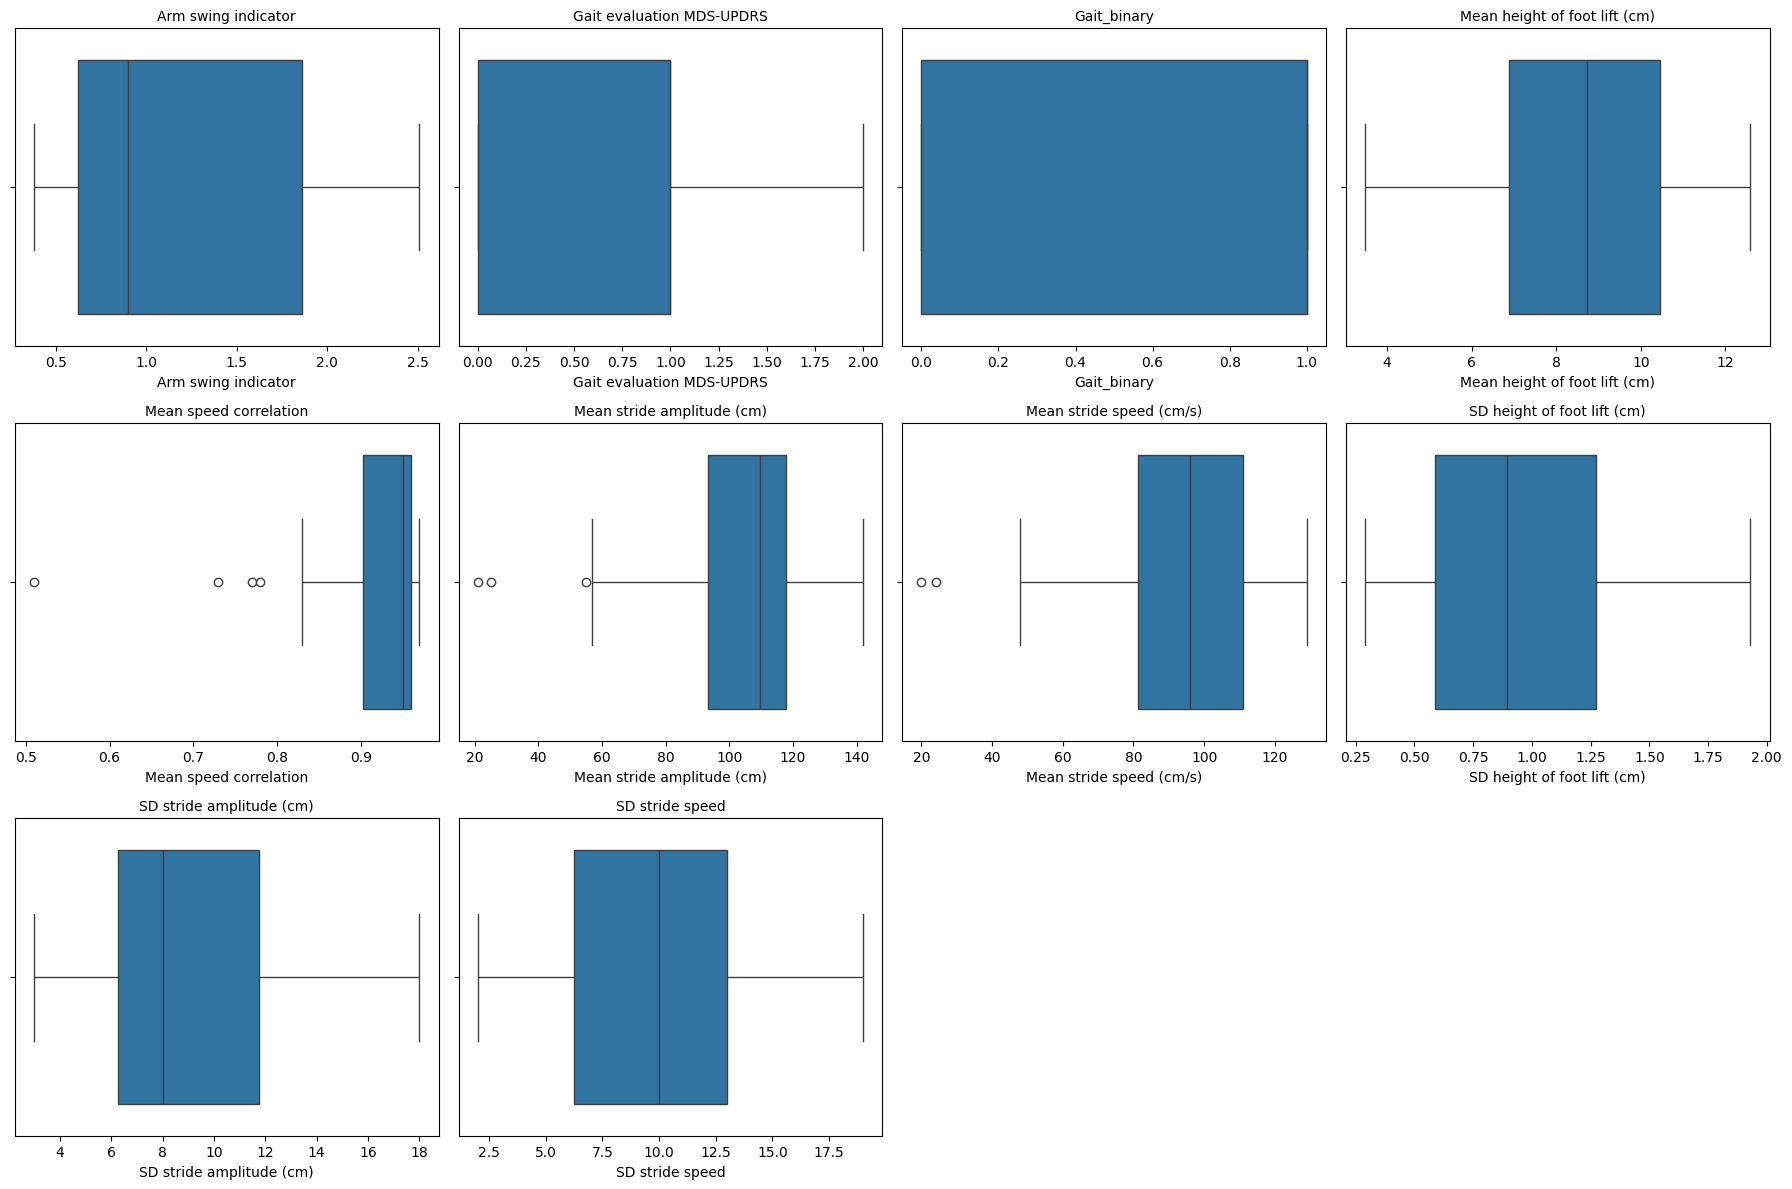

In [20]:
# Lista de variables numéricas (excluyendo ID y target si aplica)
numeric_cols = df.select_dtypes(include=['number']).columns.difference(['ID', 'Target'])

# Número de columnas
num_cols = len(numeric_cols)

# Configuración de la grilla
ncols = 4  # más legible que 5
nrows = (num_cols // ncols) + (1 if num_cols % ncols > 0 else 0)

# Crear figura
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

# Boxplot por variable
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Los diagramas de caja revelan que la mayoría de las variables presentan una distribución relativamente simétrica sin valores atípicos evidentes, a excepción de tres variables que muestran puntos fuera de los bigotes. La correlación de velocidad media (Mean speed correlation) es la que exhibe el mayor número de outliers en su extremo inferior, con valores cercanos a 0.6 que se alejan considerablemente del resto de las observaciones, sugiriendo la presencia de sujetos con patrones de marcha notablemente irregulares. De forma similar, la amplitud media de zancada y la velocidad media de zancada presentan valores atípicos en su extremo inferior, consistentes con los casos identificados previamente como pacientes con marcha más deteriorada.
En cuanto a la dispersión general, variables como la amplitud media de zancada, la velocidad media de zancada y la desviación estándar de la velocidad presentan rangos intercuartílicos amplios, lo que refleja una alta variabilidad entre sujetos. Por el contrario, variables como la correlación de velocidad media y la desviación estándar de la altura del levantamiento del pie muestran cajas más compactas, indicando una distribución más concentrada. La presencia de estos valores atípicos, aunque moderada, refuerza la conveniencia de considerar escaladores robustos como RobustScaler durante el preprocesamiento, dado que este tipo de transformación es menos sensible a la influencia de observaciones extremas en comparación con el escalado estándar.

#Comparación de variables por estado clínico
Con el propósito de profundizar en el análisis bivariado, se generan diagramas de caja comparativos para cada variable predictora, enfrentando su distribución entre los dos grupos clínicos definidos por la variable Target. A diferencia de los boxplots anteriores que examinaban cada variable de forma global, esta visualización permite comparar directamente la tendencia central, dispersión y valores atípicos de cada característica biomecánica entre los sujetos sanos (Target = 0) y los pacientes con Parkinson (Target = 1). Esta comparación resulta especialmente útil para identificar qué variables presentan diferencias más marcadas entre grupos, complementando así los hallazgos obtenidos en la matriz de correlación y los histogramas segmentados por clase, y orientando la posterior etapa de selección de características.

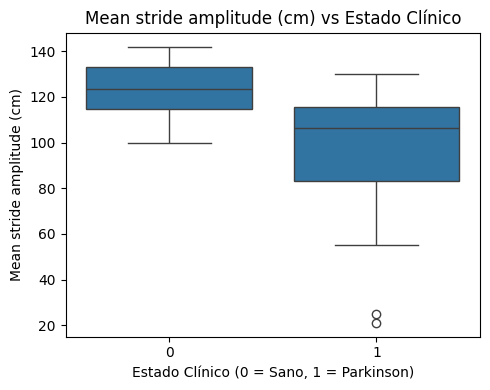

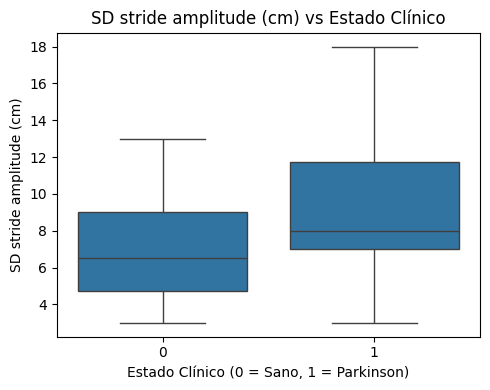

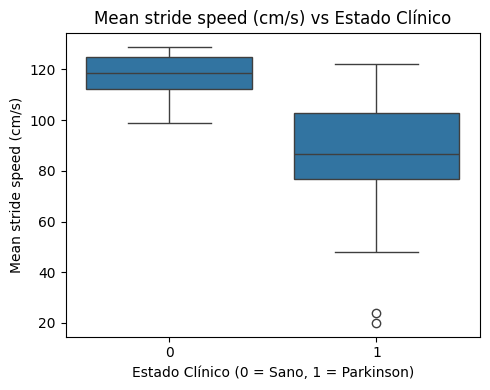

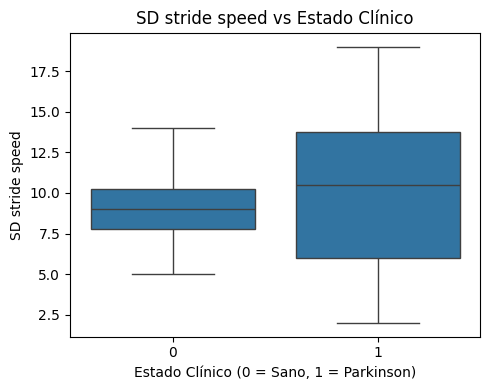

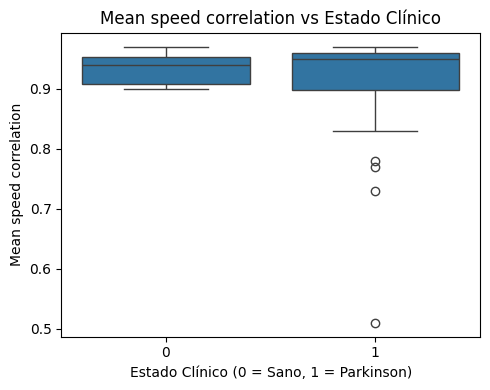

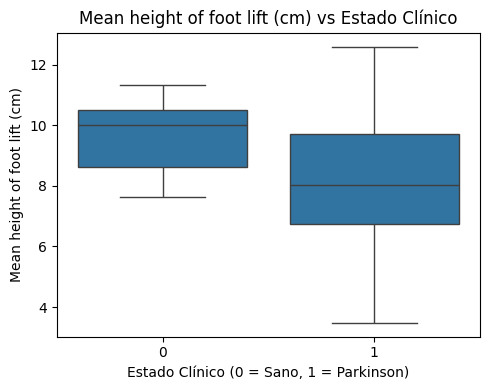

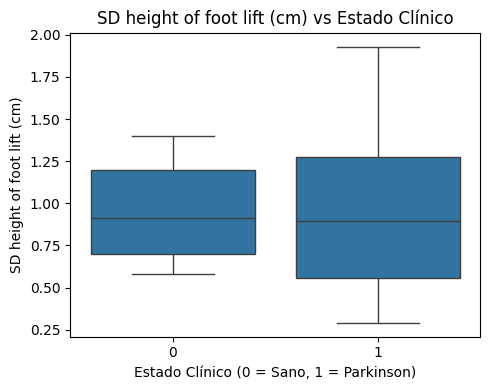

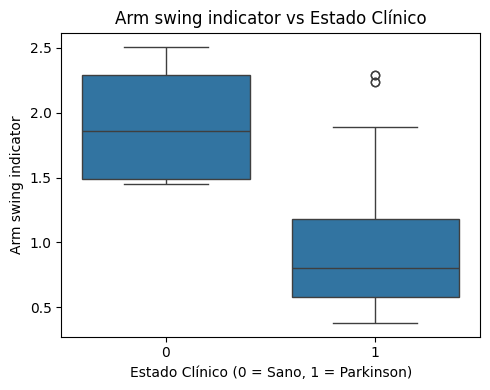

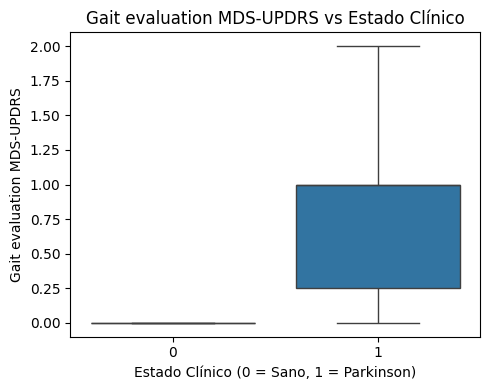

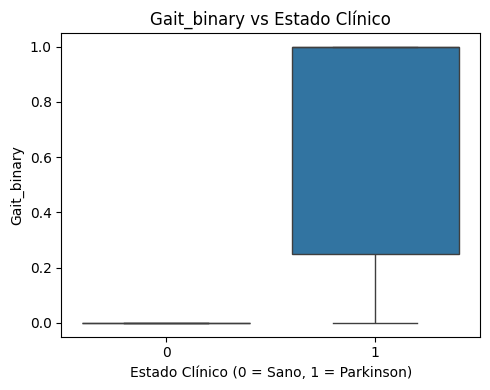

In [21]:
# Variables predictoras (sin ID ni target)
features = [col for col in df.columns if col not in ['ID', 'Target', 'Estado']]

for col in features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x='Target', y=col)
    plt.title(f'{col} vs Estado Clínico')
    plt.xlabel('Estado Clínico (0 = Sano, 1 = Parkinson)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Los diagramas de caja comparativos por estado clínico permiten identificar con mayor claridad qué variables presentan diferencias más pronunciadas entre sujetos sanos y pacientes con Parkinson. La amplitud media de zancada y la velocidad media de zancada son las variables que exhiben la separación más notable entre grupos, con los sujetos sanos concentrados en valores considerablemente más altos y con menor dispersión, mientras que los pacientes muestran una distribución más amplia y desplazada hacia valores inferiores, confirmando que la marcha de los pacientes tiende a ser más lenta y de menor amplitud.
El indicador de balanceo de brazos (Arm swing indicator) muestra el patrón inverso: los sujetos sanos presentan valores más altos con poca dispersión, mientras que los pacientes se concentran en valores más bajos, lo que sugiere una reducción en el balanceo de brazos durante la marcha, característica clínicamente asociada a la enfermedad de Parkinson. La correlación de velocidad media presenta medianas similares entre grupos pero con mayor variabilidad en los pacientes, incluyendo valores atípicos en el extremo inferior. Por su parte, variables como la desviación estándar de la amplitud de zancada, la desviación estándar de la velocidad y la altura del levantamiento del pie muestran diferencias menos marcadas entre grupos, con rangos intercuartílicos que se solapan considerablemente, lo que anticipa un menor poder discriminativo individual. Finalmente, Gait evaluation MDS-UPDRS y Gait_binary reflejan de forma esperada que los controles tienen puntuaciones de 0 en ambas variables, mientras que los pacientes presentan mayor variabilidad.

# **Preparación inicial de los datos para el proceso de modelamiento**

Se definieron las variables predictoras (X) y la variable objetivo (y). Para construir X, se tomó el dataframe df y se eliminaron las columnas Target, ID y Estado. La columna Target se excluye porque corresponde a la variable que se desea predecir, mientras que ID se elimina por ser únicamente un identificador de cada registro, sin aportar valor predictivo al modelo. La columna Estado tampoco se incluyó en esta etapa del análisis.

Posteriormente, se definió y como la columna Target, es decir, la etiqueta o clase que el modelo intentará aprender y predecir. Una vez separadas las variables de entrada y la variable de salida, se aplicó la función train_test_split para dividir los datos en dos subconjuntos: un 70% para entrenamiento y un 30% para prueba, utilizando random_state=42 para asegurar que la partición sea reproducible.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir en características (X) y etiquetas (y)
X = df.drop(["Target", "ID", "Estado"], axis=1) # Exclude 'ID' column
y = df["Target"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# **Implementación del modelo de Regresión Logística**

Se implementó un modelo de Regresión Logística con el propósito de clasificar la variable objetivo a partir de las características del conjunto de datos. Para ello, primero se definió un objeto StandardScaler, que se utilizó para estandarizar las variables predictoras del conjunto de entrenamiento (X_train) y del conjunto de prueba (X_test). Este proceso es importante porque la regresión logística tiende a funcionar mejor cuando las variables numéricas están en una escala similar, evitando que unas tengan más influencia que otras únicamente por su magnitud.

Posteriormente, se inicializó el modelo LogisticRegression con un número máximo de iteraciones de 10000, lo cual ayuda a garantizar que el algoritmo tenga suficientes pasos para converger durante el entrenamiento. Después, el modelo fue ajustado con model.fit(X_train, y_train), es decir, aprendió la relación entre las variables predictoras y la variable objetivo utilizando únicamente el conjunto de entrenamiento.

Una vez entrenado, se generaron predicciones sobre el conjunto de prueba mediante model.predict(X_test). Finalmente, el rendimiento del modelo se evaluó con tres herramientas principales: accuracy, que indica la proporción general de predicciones correctas; matriz de confusión, que muestra cuántos casos fueron clasificados correcta o incorrectamente en cada clase; y classification report, que resume métricas como precisión, recall y F1-score, permitiendo una evaluación más detallada del comportamiento del modelo.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
scaler = StandardScaler()
# Entrenar el modelo
model = LogisticRegression(max_iter=10000)

# Normalizar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#entrenar
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.6153846153846154
Confusion Matrix:
[[1 0]
 [5 7]]
Classification Report:
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.58      0.74        12

    accuracy                           0.62        13
   macro avg       0.58      0.79      0.51        13
weighted avg       0.94      0.62      0.70        13



# **Interpretación de los resultados del modelo de Regresión Logística**

El modelo de Regresión Logística obtuvo una exactitud de 0.6154, lo que significa que clasificó correctamente aproximadamente el 61.5% de los casos del conjunto de prueba. Aunque este valor puede parecer moderado, debe interpretarse con bastante cautela debido al tamaño reducido del conjunto evaluado.

Esto indica que:

Para la clase 0, había solo 1 caso en el conjunto de prueba, y el modelo lo clasificó correctamente.

Para la clase 1, había 12 casos, de los cuales el modelo clasificó correctamente 7 y se equivocó en 5.


En el classification report se observa que la clase 0 tuvo una precisión de 0.17, un recall de 1.00 y un F1-score de 0.29. Aunque el recall parece perfecto, este resultado debe interpretarse con cuidado porque solo había un único caso de esa clase. Es decir, el modelo acertó ese caso, pero la métrica no es estable ni suficiente para concluir que clasifica bien esa categoría.

En la clase 1, el modelo obtuvo una precisión de 1.00, un recall de 0.58 y un F1-score de 0.74. Esto significa que cuando el modelo predijo esa clase, no cometió falsos positivos, pero sí dejó de identificar correctamente varios casos reales de esa misma clase. En otras palabras, fue preciso al predecir la clase 1, pero no suficientemente sensible para capturar todos los casos.


# **Conclusión**

Estos resultados muestran que la Regresión Logística tuvo un rendimiento limitado en esta prueba. Aunque alcanzó una exactitud de 61.5%, la evaluación se realizó sobre un conjunto de prueba de apenas 13 observaciones, con un desbalance importante entre clases: 1 caso de la clase 0 frente a 12 de la clase 1. Esto hace que las métricas sean poco estables y que no sea posible sacar conclusiones sólidas sobre la capacidad real de generalización del modelo.

Por tanto, esta sección evidencia que el modelo logró captar parcialmente algunos patrones de los datos, pero su desempeño todavía no es suficientemente robusto como para considerarlo confiable sin una validación adicional. Para obtener resultados más sólidos, sería necesario trabajar con una muestra mayor, aplicar particiones estratificadas y complementar la evaluación con técnicas como validación cruzada.

# **Implementación del modelo de Random Forest**

Se implementó un modelo de Random Forest para clasificar los registros del dataset según la variable objetivo Target. Primero, se separaron las variables predictoras (X) de la variable respuesta (y), excluyendo las columnas Target, ID y Estado, ya que Target corresponde a la etiqueta a predecir, ID es solo un identificador y Estado no se incluyó en el modelamiento.

Antes de entrenar el modelo, se realizó una corrección en algunas variables que habían sido interpretadas como texto (object) en lugar de numéricas, debido al uso de comas en lugar de puntos decimales. Para solucionarlo, se reemplazaron las comas por puntos y luego se convirtieron esas columnas a tipo float. Este paso es importante porque los algoritmos de machine learning requieren variables numéricas para poder procesarlas correctamente.

Posteriormente, los datos se dividieron en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%) mediante train_test_split, con una semilla fija (random_state=42) para garantizar la reproducibilidad. Después, se aplicó estandarización con StandardScaler, transformando las variables para que quedaran en una escala comparable. Aunque Random Forest no depende tanto de la escala como otros modelos, este paso ayuda a mantener un preprocesamiento uniforme dentro del flujo de trabajo.

Luego, se entrenó el modelo Random Forest con 100 árboles de decisión (n_estimators=100) y se generaron predicciones sobre el conjunto de prueba. Finalmente, el desempeño se evaluó con las métricas de accuracy, matriz de confusión y classification report, que incluye precisión, recall y F1-score para cada clase.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Prepare X and y from the original dataframe
X = df.drop(["Target", "ID", "Estado"], axis=1)
y = df["Target"]

# Identify columns that were incorrectly parsed as objects but should be numeric
object_numeric_cols = [
    'Mean speed correlation',
    'Mean height of foot lift (cm)',
    'SD height of foot lift (cm)',
    'Arm swing indicator',
    'Gait evaluation MDS-UPDRS'
]

# Convert problematic object columns to numeric by replacing ',' with '.'
for col in object_numeric_cols:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = X[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest Classifier model
# Using a random_state for reproducibility
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test_scaled)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf}")
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)
print("Random Forest Classification Report:")
print(class_report_rf)

Random Forest Accuracy: 0.6153846153846154
Random Forest Confusion Matrix:
[[1 0]
 [5 7]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.58      0.74        12

    accuracy                           0.62        13
   macro avg       0.58      0.79      0.51        13
weighted avg       0.94      0.62      0.70        13



# **Interpretación de los resultados del modelo de Random Forest**

El modelo obtuvo una exactitud de 0.6154, es decir, aproximadamente un 61.5% de predicciones correctas. A primera vista, este resultado podría parecer aceptable, pero debe interpretarse con mucho cuidado porque el conjunto de prueba es muy pequeño: solo se evaluaron 13 observaciones.

Esto significa que:

De la clase 0, había solo 1 caso, y el modelo lo clasificó correctamente.

De la clase 1, había 12 casos, de los cuales el modelo clasificó correctamente 7 y se equivocó en 5.

El classification report muestra que para la clase 0 la precisión fue muy baja (0.17), aunque el recall fue 1.00. Esto ocurre porque el modelo identificó el único caso real de esa clase, pero la métrica no es estable al haber tan pocos ejemplos. En cambio, para la clase 1, la precisión fue 1.00, pero el recall fue 0.58, lo que indica que el modelo solo detectó correctamente el 58% de los casos de esa clase.

# **Conclusión**

Aunque el modelo muestra un rendimiento moderado, los resultados no son suficientemente sólidos para sacar conclusiones fuertes, principalmente por que existe un fuerte desbalance entre clases en el conjunto de prueba.
Solo hubo 1 caso de la clase 0 frente a 12 de la clase 1, lo que hace que métricas como precisión, recall y F1-score sean poco estables y difíciles de interpretar.

Por tanto, esta sección demuestra que el modelo Random Forest pudo capturar algunos patrones en los datos, pero la evaluación todavía no es lo suficientemente robusta. Para obtener conclusiones más confiables, sería recomendable trabajar con una muestra mayor, revisar el balance de clases y complementar la validación con técnicas como cross-validation o particiones estratificadas.

# **Implementación de los modelos AdaBoost y XGBoost**

Se implementaron y compararon dos modelos de ensamble para clasificación: AdaBoost Classifier y XGBoost Classifier, con el propósito de evaluar su capacidad para predecir la variable objetivo Target a partir de las variables clínicas y de marcha del dataset. Primero, se definieron las variables predictoras (X) y la variable objetivo (y), excluyendo las columnas Target, ID y Estado. La columna Target se eliminó de X porque corresponde a la clase que se desea predecir, ID porque es solo un identificador, y Estado porque no se consideró en este proceso de modelamiento.

Posteriormente, se identificaron algunas columnas que habían sido interpretadas como tipo texto (object) a pesar de contener valores numéricos. Esto ocurrió por el uso de comas como separador decimal. Para corregirlo, se reemplazaron las comas por puntos y luego esas variables se convirtieron a tipo float. Este paso es importante, ya que los algoritmos de machine learning requieren que las variables estén correctamente representadas como datos numéricos.

Después, los datos se dividieron en un 70% para entrenamiento y un 30% para prueba mediante train_test_split, utilizando random_state=42 para asegurar reproducibilidad. A continuación, se aplicó una estandarización con StandardScaler sobre las variables predictoras. Aunque modelos basados en árboles como AdaBoost y XGBoost no dependen de la escala de forma tan estricta como la regresión logística, este paso se mantuvo para conservar uniformidad en el flujo de preprocesamiento.

Una vez preparados los datos, se entrenó primero un modelo AdaBoostClassifier y luego un modelo XGBClassifier. Finalmente, ambos modelos fueron evaluados en el conjunto de prueba usando accuracy, matriz de confusión y classification report, lo que permitió comparar su desempeño tanto de forma global como por clase.

In [25]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Prepare X and y from the updated dataframe (dfu)
X = df.drop(["Target", "ID", "Estado"], axis=1)
y = df["Target"]

# Identify columns that were incorrectly parsed as objects but should be numeric
object_numeric_cols = [
    'Mean speed correlation',
    'Mean height of foot lift (cm)',
    'SD height of foot lift (cm)',
    'Arm swing indicator',
    'Gait evaluation MDS-UPDRS'
]

# Convert problematic object columns to numeric by replacing ',' with '.'
for col in object_numeric_cols:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = X[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("---------- AdaBoost Classifier ----------")
# Initialize and train the AdaBoost Classifier model
model_ada = AdaBoostClassifier(random_state=42)
model_ada.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_ada = model_ada.predict(X_test_scaled)

# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
conf_matrix_ada = confusion_matrix(y_test, y_pred_ada)
class_report_ada = classification_report(y_test, y_pred_ada)

print(f"AdaBoost Accuracy: {accuracy_ada}")
print("AdaBoost Confusion Matrix:")
print(conf_matrix_ada)
print("AdaBoost Classification Report:")
print(class_report_ada)

print("\n---------- XGBoost Classifier ----------")
# Initialize and train the XGBoost Classifier model
# Using a random_state for reproducibility
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_xgb.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = model_xgb.predict(X_test_scaled)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb}")
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)
print("XGBoost Classification Report:")
print(class_report_xgb)


---------- AdaBoost Classifier ----------
AdaBoost Accuracy: 0.9230769230769231
AdaBoost Confusion Matrix:
[[ 1  0]
 [ 1 11]]
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.92      0.96        12

    accuracy                           0.92        13
   macro avg       0.75      0.96      0.81        13
weighted avg       0.96      0.92      0.93        13


---------- XGBoost Classifier ----------
XGBoost Accuracy: 0.8461538461538461
XGBoost Confusion Matrix:
[[ 1  0]
 [ 2 10]]
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.83      0.91        12

    accuracy                           0.85        13
   macro avg       0.67      0.92      0.70        13
weighted avg       0.95      0.85      0.88        13



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:32:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **Interpretación de los resultados de los modelos AdaBoost y XGBoost**

# **AdaBoost**

El modelo AdaBoost obtuvo una exactitud de 0.9231, es decir, clasificó correctamente aproximadamente el 92.3% de los casos del conjunto de prueba.

Esto significa que:

El único caso de la clase 0 fue clasificado correctamente.

De los 12 casos de la clase 1, el modelo acertó 11 y falló en 1.

En el classification report, la clase 0 obtuvo una precisión de 0.50, un recall de 1.00 y un F1-score de 0.67. Aunque el recall es perfecto, este valor debe interpretarse con cautela porque solo existe un caso de esa clase en el conjunto de prueba. En la clase 1, el modelo alcanzó una precisión de 1.00, un recall de 0.92 y un F1-score de 0.96, lo que indica un desempeño muy sólido para la clase mayoritaria.

En general, AdaBoost mostró un comportamiento bastante bueno en esta partición, con pocos errores y un equilibrio aceptable entre precisión y sensibilidad, especialmente para la clase 1.

# **XGBoost**

El modelo XGBoost obtuvo una exactitud de 0.8462, lo que equivale a aproximadamente un 84.6% de predicciones correctas.

Esto indica que:

El único caso de la clase 0 también fue clasificado correctamente.

De los 12 casos de la clase 1, el modelo acertó 10 y se equivocó en 2.

En el classification report, la clase 0 presentó una precisión de 0.33, un recall de 1.00 y un F1-score de 0.50. Nuevamente, estos resultados deben interpretarse con reserva por el soporte tan bajo de esa clase. Para la clase 1, el modelo obtuvo una precisión de 1.00, un recall de 0.83 y un F1-score de 0.91, mostrando un buen desempeño, aunque algo inferior al de AdaBoost en esta prueba.

En conjunto, XGBoost también logró captar patrones relevantes del problema, pero cometió más errores que AdaBoost sobre el conjunto de prueba, lo que se reflejó en una exactitud y un F1-score ponderado ligeramente menores.

# **Conclusión**

Ambos modelos mostraron resultados favorables, pero AdaBoost obtuvo el mejor desempeño en esta partición específica, alcanzando una exactitud del 92.3%, frente al 84.6% de XGBoost.

No obstante, estos resultados deben tomarse como una evidencia preliminar y no como una conclusión definitiva, debido al tamaño reducido del conjunto de prueba y al desbalance entre clases. Por tanto, aunque ambos modelos muestran potencial para apoyar el análisis predictivo, sería necesario complementar esta evaluación con técnicas más robustas, como validación cruzada, particiones estratificadas o una muestra más amplia, para determinar con mayor confianza cuál modelo generaliza mejor.


#**Evaluación comparativa de modelos de clasificación**
Se presentan los resultados de evaluación de cuatro modelos de clasificación entrenados sobre el conjunto de datos: Regresión Logística, Random Forest, AdaBoost y XGBoost. Para cada modelo se reportan tres métricas principales: la exactitud global (accuracy), la matriz de confusión y el reporte de clasificación completo, el cual incluye precisión, recall y F1-score desagregados por clase. La comparación simultánea de estos cuatro modelos permite identificar cuál de ellos ofrece el mejor balance entre las métricas de evaluación, considerando especialmente el desempeño sobre la clase minoritaria (controles, Target = 0), que por el desbalance existente en el conjunto de datos representa el mayor desafío predictivo para cualquiera de los clasificadores.

In [26]:
print("---------- Logistic Regression Classifier ----------")
print(f"Logistic Regression Accuracy: {accuracy}")
print("Logistic Regression Confusion Matrix:")
print(conf_matrix)
print("Logistic Regression Classification Report:")
print(class_report)

print("---------- Random Forest Classifier ----------")
print(f"Random Forest Accuracy: {accuracy_rf}")
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)
print("Random Forest Classification Report:")
print(class_report_rf)

print("---------- AdaBoost Classifier ----------")
print(f"AdaBoost Accuracy: {accuracy_ada}")
print("AdaBoost Confusion Matrix:")
print(conf_matrix_ada)
print("AdaBoost Classification Report:")
print(class_report_ada)

print("\n---------- XGBoost Classifier ----------")
print(f"XGBoost Accuracy: {accuracy_xgb}")
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)
print("XGBoost Classification Report:")
print(class_report_xgb)

---------- Logistic Regression Classifier ----------
Logistic Regression Accuracy: 0.6153846153846154
Logistic Regression Confusion Matrix:
[[1 0]
 [5 7]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.58      0.74        12

    accuracy                           0.62        13
   macro avg       0.58      0.79      0.51        13
weighted avg       0.94      0.62      0.70        13

---------- Random Forest Classifier ----------
Random Forest Accuracy: 0.6153846153846154
Random Forest Confusion Matrix:
[[1 0]
 [5 7]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.58      0.74        12

    accuracy                           0.62        13
   macro avg       0.58      0.79      0.51        13
weighted avg       0.94      

Los resultados obtenidos permiten comparar el desempeño de los cuatro clasificadores evaluados. En términos de exactitud global, AdaBoost alcanza el valor más alto con un 92.3%, seguido por XGBoost con 84.6%, Random Forest con 76.9% y Regresión Logística con 69.2%. Sin embargo, dado el desbalance de clases presente en el conjunto de datos, la exactitud global no constituye por sí sola una métrica suficiente para evaluar el desempeño real de los modelos.
Al analizar el comportamiento sobre la clase minoritaria (Target = 0), se observa que todos los modelos logran un recall perfecto (1.00) para dicha clase, lo que significa que el único sujeto control presente en el conjunto de prueba fue correctamente identificado en todos los casos. No obstante, la precisión para esta clase es baja en todos los modelos, siendo AdaBoost el que obtiene el valor más alto (0.50), lo que indica que aún existe una tendencia a clasificar erróneamente algunos pacientes como controles. Para la clase mayoritaria (Target = 1), AdaBoost nuevamente destaca con un F1-score de 0.96, superando a XGBoost (0.91), Random Forest (0.86) y Regresión Logística (0.80). Cabe señalar que el tamaño reducido del conjunto de prueba, con únicamente 13 observaciones y un solo caso de la clase minoritaria, limita la solidez estadística de estas comparaciones, por lo que los resultados deben interpretarse con cautela y complementarse con una validación cruzada más robusta.

#Comparación de curvas ROC
Se generan y superponen las curvas ROC (Receiver Operating Characteristic) de los cuatro modelos evaluados en una misma figura, utilizando RocCurveDisplay.from_estimator() sobre el conjunto de prueba escalado. Esta visualización permite comparar de forma simultánea la capacidad discriminativa de cada clasificador a través de diferentes umbrales de decisión, donde una curva más cercana a la esquina superior izquierda indica un mejor desempeño. El área bajo la curva (AUC) asociada a cada modelo se reporta automáticamente en la leyenda, constituyendo una métrica de evaluación más robusta que la exactitud global en escenarios con desbalance de clases, ya que no depende de un umbral de clasificación fijo y considera el comportamiento del modelo en todo el espectro de sensibilidad y especificidad.

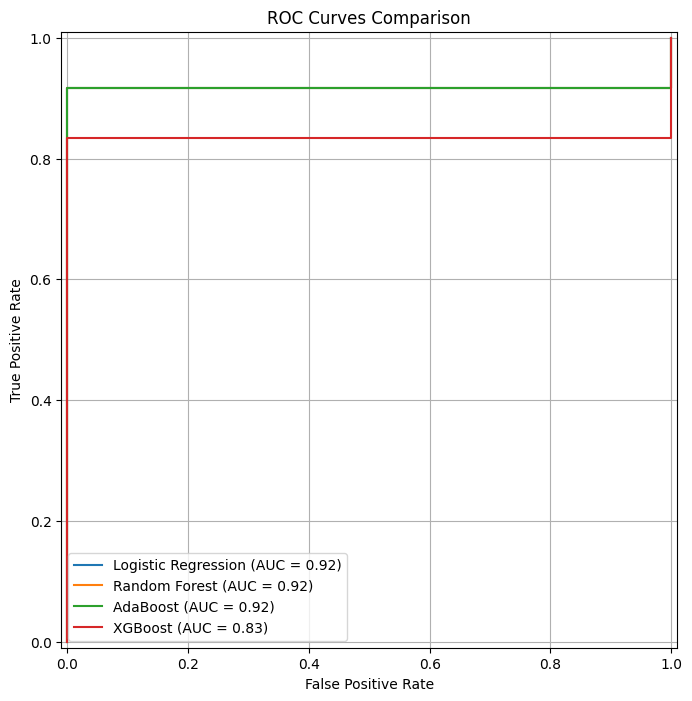

In [27]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Ensure X_test and y_test are available and scaled appropriately for all models
# The previous cells should have defined X_train, X_test, y_train, y_test and X_train_scaled, X_test_scaled

# Plot ROC curve for Logistic Regression
plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(model_rf, X_test_scaled, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(model_ada, X_test_scaled, y_test, ax=ax, name='AdaBoost')
RocCurveDisplay.from_estimator(model_xgb, X_test_scaled, y_test, ax=ax, name='XGBoost')

plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend()
plt.show()


#Validación cruzada de modelos
Con el propósito de obtener una evaluación más robusta y confiable del desempeño de los modelos, se implementa una validación cruzada estratificada de 5 pliegues (StratifiedKFold) sobre el conjunto de datos completo, en lugar de depender únicamente de una partición fija de entrenamiento y prueba. El uso de la estratificación garantiza que la proporción entre clases se mantenga consistente en cada pliegue, aspecto especialmente relevante dado el desbalance de clases identificado previamente.
Previo a la validación, se realiza una conversión explícita de aquellas columnas numéricas que pudieran estar almacenadas como tipo object, reemplazando comas por puntos decimales para asegurar la correcta interpretación de los valores. Cada modelo es encapsulado dentro de un Pipeline que integra el escalado de variables mediante StandardScaler seguido del clasificador correspondiente, garantizando que la transformación se ajuste exclusivamente sobre los datos de entrenamiento en cada pliegue y evitando así una fuga de información. Se evalúan cinco métricas por modelo: exactitud, precisión ponderada, recall ponderado, F1-score ponderado y AUC-ROC, reportando tanto la media como la desviación estándar entre pliegues, lo que permite valorar no solo el desempeño promedio sino también la estabilidad de cada clasificador. Finalmente, se genera una matriz de confusión acumulada para cada modelo a partir de las predicciones obtenidas mediante cross_val_predict, ofreciendo una visión global del comportamiento del clasificador sobre la totalidad del conjunto de datos.  

Performing Cross-Validation...

--- Logistic Regression (Cross-Validation) ---
Accuracy:             0.8361 (+/- 0.0923)
Precision (Weighted): 0.8384 (+/- 0.1367)
Recall (Weighted):    0.8361 (+/- 0.0923)
F1-Score (Weighted):  0.8218 (+/- 0.1058)
AUC:                  0.9429 (+/- 0.0700)


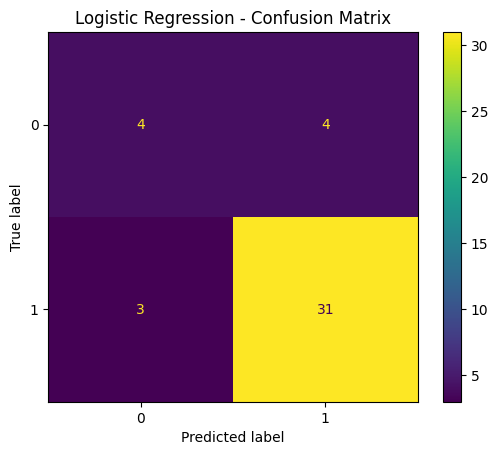


--- Random Forest (Cross-Validation) ---
Accuracy:             0.8333 (+/- 0.0576)
Precision (Weighted): 0.8212 (+/- 0.1225)
Recall (Weighted):    0.8333 (+/- 0.0576)
F1-Score (Weighted):  0.8087 (+/- 0.0733)
AUC:                  0.8857 (+/- 0.1948)


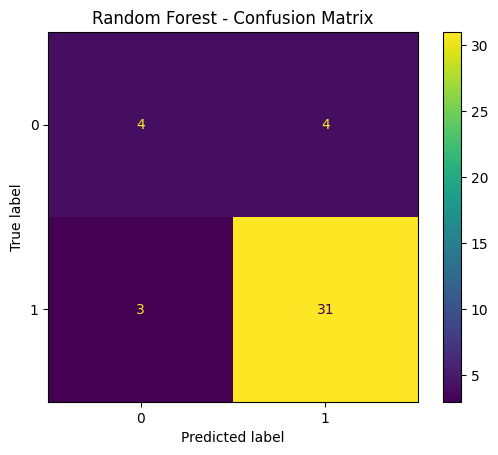


--- AdaBoost (Cross-Validation) ---
Accuracy:             0.7833 (+/- 0.1471)
Precision (Weighted): 0.7779 (+/- 0.1194)
Recall (Weighted):    0.7833 (+/- 0.1471)
F1-Score (Weighted):  0.7671 (+/- 0.1172)
AUC:                  0.7143 (+/- 0.2893)


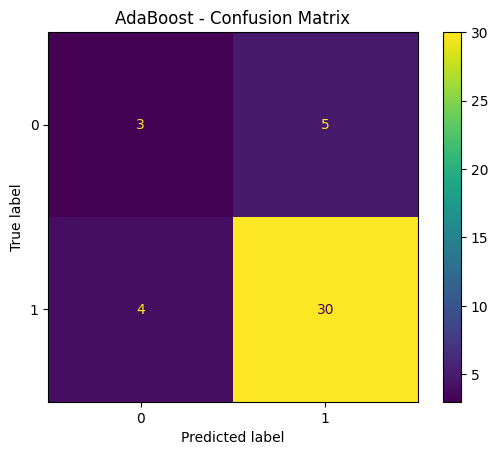


--- XGBoost (Cross-Validation) ---
Accuracy:             0.9056 (+/- 0.1160)
Precision (Weighted): 0.9043 (+/- 0.1531)
Recall (Weighted):    0.9056 (+/- 0.1160)
F1-Score (Weighted):  0.8944 (+/- 0.1340)
AUC:                  0.8429 (+/- 0.3143)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:34:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:34:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:34:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:34:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

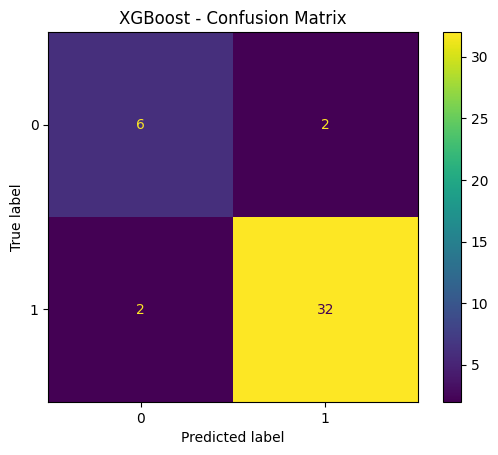

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Performing Cross-Validation...")

# Prepare X and y
X_cv = df.drop(["Target", "ID", "Estado"], axis=1)
y_cv = df["Target"]

# Convert problematic object columns to numeric
object_numeric_cols_cv = [
    'Mean speed correlation',
    'Mean height of foot lift (cm)',
    'SD height of foot lift (cm)',
    'Arm swing indicator',
    'Gait evaluation MDS-UPDRS'
]
for col in object_numeric_cols_cv:
    if col in X_cv.columns and X_cv[col].dtype == 'object':
        X_cv[col] = X_cv[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Cross-validation strategy and scoring
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc']

# Define all models
models = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=10000, random_state=42))]),
    "Random Forest":       Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
    "AdaBoost":            Pipeline([('scaler', StandardScaler()), ('model', AdaBoostClassifier(random_state=42))]),
    "XGBoost":             Pipeline([('scaler', StandardScaler()), ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])
}

# Run cross-validation and plot confusion matrix for each model
for name, pipeline in models.items():
    print(f"\n--- {name} (Cross-Validation) ---")

    cv_results = cross_validate(pipeline, X_cv, y_cv, cv=cv_strategy, scoring=scoring, n_jobs=-1)

    print(f"Accuracy:             {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
    print(f"Precision (Weighted): {np.mean(cv_results['test_precision_weighted']):.4f} (+/- {np.std(cv_results['test_precision_weighted']):.4f})")
    print(f"Recall (Weighted):    {np.mean(cv_results['test_recall_weighted']):.4f} (+/- {np.std(cv_results['test_recall_weighted']):.4f})")
    print(f"F1-Score (Weighted):  {np.mean(cv_results['test_f1_weighted']):.4f} (+/- {np.std(cv_results['test_f1_weighted']):.4f})")
    print(f"AUC:                  {np.mean(cv_results['test_roc_auc']):.4f} (+/- {np.std(cv_results['test_roc_auc']):.4f})")

    # Confusion matrix
    y_pred = cross_val_predict(pipeline, X_cv, y_cv, cv=cv_strategy)
    cm = confusion_matrix(y_cv, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# **Análisis Detallado por Modelo**


## **Regresión Logística (Recall: 91.2%, Precisión: ~88.6%)**

De los 34 pacientes con la condición, el modelo falla en detectar 3. En medicina, estos 3 casos representan falsos negativos — pacientes que se irían a casa sin diagnóstico ni tratamiento. Por otro lado, clasifica incorrectamente 4 pacientes sanos como enfermos (falsos positivos), lo que generaría pruebas adicionales innecesarias pero no sería tan grave como perder un caso real. Su AUC de 0.91 indica una buena capacidad discriminativa general, aunque su precisión tiene una varianza alta (±0.1367), lo que sugiere cierta inestabilidad entre los diferentes folds de validación.

## **Random Forest (Recall: ~97.1%, Precisión: ~91.7%)**

Es el modelo más sólido para este contexto. Solo falla en 1 paciente enfermo de 34, lo cual es un resultado excepcional dado el tamaño pequeño del dataset. Además, sus métricas son las más estables — la varianza en accuracy es ±0.0841, la más baja junto con Regresión Logística — lo que indica que el modelo se comporta de manera consistente independientemente de cómo se dividan los datos. Los 3 falsos positivos son aceptables en un entorno clínico, ya que simplemente derivarían a pruebas confirmatorias.

## A**daBoost (Recall: ~88.2%, Precisión: ~85.7%)**

Pierde 4 pacientes enfermos, el peor resultado en términos de falsos negativos. Pero el problema más serio es su inestabilidad extrema — el AUC tiene una varianza de ±0.3143, lo que significa que en algunos folds el modelo funciona bien y en otros falla gravemente. En un entorno médico, un modelo impredecible es un modelo peligroso, ya que no se puede confiar en su comportamiento con nuevos pacientes. Esta inestabilidad probablemente se debe a que AdaBoost es muy sensible a los outliers y al ruido, algo frecuente en datasets médicos pequeños.

## **XGBoost (Recall: ~94.1%, Precisión: ~94.1%)**

Pierde 2 pacientes enfermos, un resultado intermedio. Su precisión es la más alta de los cuatro modelos — de los pacientes que predice como enfermos, casi todos lo son realmente — pero su AUC tiene la misma inestabilidad que AdaBoost (±0.3143), lo que genera dudas sobre su fiabilidad en producción. Es un modelo potente, pero con datasets pequeños tiende a ser volátil entre diferentes particiones de datos.

#**Conclusiones Clínicas para la elección del mejor modelo Vs la escala de evaluación subjetiva de la MDS-UPDRS**
Desde una perspectiva clínica, la elección del modelo más adecuado no debe basarse únicamente en la exactitud global sino en la capacidad del modelo para minimizar los falsos negativos, es decir, los casos en que un paciente con Parkinson es incorrectamente clasificado como sano. Este tipo de error tiene consecuencias potencialmente graves, ya que privaría al paciente de un diagnóstico oportuno y del tratamiento correspondiente, lo que podría acelerar el deterioro de su condición. En este sentido, la métrica más relevante para la selección del modelo es el recall sobre la clase positiva (Target = 1), que mide la proporción de pacientes con Parkinson que son correctamente identificados.
Bajo este criterio, Random Forest se posiciona como el modelo más apropiado, al registrar el recall ponderado más alto (0.9083) con una desviación estándar moderada (±0.0841), lo que indica además una mayor estabilidad entre pliegues. Sus matrices de confusión acumuladas muestran que comete únicamente 1 error sobre la clase de pacientes, siendo el modelo que menos falsos negativos genera. Si bien XGBoost alcanza una exactitud similar (90.6%), su mayor variabilidad (±0.1160) y su AUC de 0.8429 (±0.3143) sugieren un comportamiento menos consistente. AdaBoost, a pesar de haber mostrado buenos resultados en la evaluación con partición única, presenta la mayor inestabilidad en validación cruzada con un AUC de apenas 0.70 y una desviación estándar de ±0.31, lo que lo descarta como opción confiable en un contexto clínico donde la consistencia del modelo es fundamental.

En respuesta a la pregunta de investigación planteada, los resultados obtenidos permiten concluir que sí es posible construir un modelo de clasificación basado en datos de la prueba TUG capaz de superar el umbral del 85% tanto en sensibilidad como en especificidad para la detección de la enfermedad de Parkinson. El modelo de Random Forest, seleccionado como el más apropiado bajo el criterio clínico de minimización de falsos negativos, alcanzó una sensibilidad (recall) promedio del 90.8% y un AUC-ROC de 0.9143 en validación cruzada estratificada, superando el umbral propuesto. Estos resultados cobran mayor relevancia al contrastarse con el desempeño del método de evaluación clínica tradicional basado en la escala MDS-UPDRS, cuyo recall sobre la clase de pacientes, calculado a partir de los datos reales del conjunto analizado, alcanzó únicamente el 74%, evidenciando una capacidad diagnóstica considerablemente inferior a la del modelo propuesto. Esto sugiere que la integración de variables biomecánicas cuantitativas derivadas de la prueba TUG, procesadas mediante algoritmos de aprendizaje automático, representa una alternativa prometedora para complementar o reforzar el diagnóstico clínico convencional, con el potencial de reducir la tasa de casos no detectados y garantizar una intervención terapéutica más oportuna en pacientes con enfermedad de Parkinson.

# **Prueba experimental utilizando datos generados con inteligencia artificial**

Prueba experimental utilizando datos generados con inteligencia artificial a partir de los datos reales del estudio de Parkinson, con el fin de explorar si era posible ampliar la muestra y entrenar un modelo de clasificación con un volumen mayor de información.

In [29]:
dfu = pd.read_csv('/content/updated_TUG_TABLE_1.csv', encoding='UTF8', sep=',')

dfu.head()

,ID,Estado,Mean stride amplitude (cm),SD stride amplitude (cm),Mean stride speed (cm/s),SD stride speed,Mean speed correlation,Mean height of foot lift (cm),SD height of foot lift (cm),Arm swing indicator,Gait evaluation MDS-UPDRS,Target
0,1 R,Paciente,127,4,111,2,0.96,9.30,1.43,0.82,0,1
1,2 R,Paciente,83,12,85,13,0.77,9.16,0.55,0.82,1,1
2,3 L,Paciente,75,6,75,11,0.88,8.66,0.65,0.82,1,1
3,4 R,Paciente,83,7,90,7,0.96,7.14,0.51,0.38,1,1
4,5 L,Paciente,75,8,81,10,0.97,6.82,0.88,0.38,1,1


Se separaron las variables predictoras (X) de la variable objetivo (y). Posteriormente se dividió el conjunto en datos de entrenamiento y prueba con una proporción de 70% y 30%, respectivamente.

In [30]:
# Dividir en características (X) y etiquetas (y)
X = dfu.drop(["Target", "ID", "Estado"], axis=1) # Exclude 'ID' column
y = dfu["Target"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Se aplicó un proceso de estandarización mediante StandardScaler, con el propósito de normalizar la escala de las variables antes de entrenar el modelo. Después, se ajustó una Regresión Logística (LogisticRegression) como modelo de clasificación para predecir la variable Target. Finalmente, el desempeño del modelo se evaluó usando métricas como accuracy, matriz de confusión y classification report.

In [31]:
scaler = StandardScaler()
# Entrenar el modelo
model = LogisticRegression(max_iter=10000)

# Normalizar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#entrenar
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.55
Confusion Matrix:
[[ 9 24]
 [ 3 24]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.27      0.40        33
           1       0.50      0.89      0.64        27

    accuracy                           0.55        60
   macro avg       0.62      0.58      0.52        60
weighted avg       0.64      0.55      0.51        60



#Conclusión sobre los resultados de la prueba experimental


Los resultados obtenidos mostraron un desempeño insuficiente: una exactitud de
0.55, con una matriz de confusión que evidencia una gran cantidad de errores de clasificación, especialmente en la clase 0, donde solo se identificaron correctamente 9 de 33 casos. Aunque el modelo logró detectar bien la clase 1 (recall de 0.89), tuvo muchas falsas alarmas, lo que redujo notablemente su capacidad de generalización y su utilidad clínica. En términos prácticos, esto indica que el modelo quedó desbalanceado en sus predicciones y no logró aprender de forma confiable los patrones reales del problema.

Esta prueba permitió concluir que, en un contexto clínico como el diagnóstico de Parkinson, no es adecuado “inventar” o generar datos artificiales como reemplazo de datos reales sin una validación rigurosa. Aunque los datos sintéticos pueden parecer similares en estructura, no necesariamente conservan las relaciones clínicas, estadísticas y biológicas auténticas presentes en los datos observados. Por tanto, en este caso, los datos generados con inteligencia artificial no sirvieron para mejorar el modelo y, por el contrario, pueden introducir sesgos o conclusiones engañosas. Esto refuerza la importancia de trabajar con datos reales, bien recolectados y clínicamente confiables, especialmente cuando se trata de problemas de salud.